# The Hubbard atom from partial spectral functions

Numerical companion to

> F. B. Kugler, S.-S. B. Lee and J. von Delft,
> *Multipoint Correlation Functions: Spectral Representation and Numerical Evaluation*,
> [Phys. Rev. X **11**, 041006 (2021)](https://doi.org/10.1103/PhysRevX.11.041006)

The plan is to assemble the Matsubara correlators of the half-filled Hubbard atom
directly from their spectral representation, and to check them against the closed
forms the paper quotes:

| Step | Content | Benchmark |
|:--|:--|:--|
| **1** | spectrum: $H$, $d_\sigma$, $d^\dagger_\sigma$, $n_\sigma$; diagonalise; $\rho_i = e^{-\beta E_i}/Z$ | $Z = 2(1+e^{\beta u})$ by hand |
| **2** | partial spectral functions, Eq. (28), general in $\ell$ | — |
| **3** | the kernel, Eq. (46), two-branch form | finite by construction |
| **4** | $\ell = 2$: assemble Eq. (39) | $G(i\nu) = \tfrac12\sum_\pm (i\nu \pm U/2)^{-1}$, App. E |
| **5** | $\ell = 4$: 24 permutations, subtract Eq. (73), amputate Eq. (76) | Eqs. (85a), (85b) |
| **6** | null test at $U = 0$ | every connected object vanishes |

**All six steps are implemented and checked**. A further section repeats the calculation in the
**Keldysh formalism** (Eqs. 49–69), reusing the same PSFs with only the kernel replaced. The last section evaluates the
vertex on 2D frequency grids and reproduces the **heat maps of Figs. 10 (MF) and 11 (KF)**, with error maps against the
analytic results. The test suite (`julia --project test/runtests.jl`) carries 58,708 assertions.

*Packages:* the sections up to the Keldysh one need only the standard library. `src/` now also uses `StaticArrays`,
and the heat-map section adds `CairoMakie`, `JLD2` and `BenchmarkTools`, all listed in `Project.toml`
(`] instantiate` in the repository installs them).

Model: $H = \varepsilon_d (n_\uparrow + n_\downarrow) + U n_\uparrow n_\downarrow$
at $\varepsilon_d = -U/2$, on the four states
$|0\rangle, |\uparrow\rangle, |\downarrow\rangle, |\uparrow\downarrow\rangle$.
This is the $U/\Delta \to \infty$ limit of the symmetric AIM, Eq. (79).

In [1]:
include(joinpath(@__DIR__, "..", "src", "HubbardAtom.jl"))
using .HubbardAtom
using LinearAlgebra
using Printf

## Step 1 — spectrum

Build the operators with correct fermionic signs, diagonalise $H$, and form the
Boltzmann weights. Everything later hangs off the eigenbasis produced here:
Eq. (28) needs the matrix elements $(O)_{i,i+1}$ in the energy eigenbasis, which
`to_eigenbasis` supplies.

The operators come from a Jordan–Wigner transform with fermionic mode order
$(\uparrow, \downarrow)$,

$$ d_\uparrow = \mathbb{1} \otimes f, \qquad d_\downarrow = f \otimes z, \qquad
   f = \begin{pmatrix} 0 & 1 \\ 0 & 0\end{pmatrix}, \quad
   z = \begin{pmatrix} 1 & 0 \\ 0 & -1\end{pmatrix}, $$

so the parity string $z$ over the $\uparrow$ mode is what produces
$d_\downarrow |\uparrow\downarrow\rangle = -|\uparrow\rangle$. That sign is not
cosmetic: it feeds every permutation sign $\zeta_p$ in Eq. (39).

In [2]:
U, β = 2.0, 5.0
model = HubbardAtomModel(U, β)
ops = operators(model)

@printf("U = %.3f,  β = %.3f,  εd = %.3f,  u = U/2 = %.3f\n",
        model.U, model.β, level_position(model), half_interaction(model))
println("\nFock basis order: ", join(BASIS_LABELS, "  "))
println("\nH (Fock basis) =")
display(ops.H)

U = 2.000,  β = 5.000,  εd = -1.000,  u = U/2 = 1.000

Fock basis order: 

|0⟩  |↑⟩  |↓⟩  |↑↓⟩

H (Fock basis) =


4×4 Matrix{Float64}:
 0.0   0.0   0.0  0.0
 0.0  -1.0   0.0  0.0
 0.0   0.0  -1.0  0.0
 0.0   0.0   0.0  0.0

In [3]:
# Fermionic algebra: the checks that catch a wrong Jordan-Wigner sign.
I4 = Matrix(1.0I, DIM, DIM)

println("{d↑, d†↑} == 1        : ", ops.d_up * ops.dag_up + ops.dag_up * ops.d_up ≈ I4)
println("{d↓, d†↓} == 1        : ", ops.d_dn * ops.dag_dn + ops.dag_dn * ops.d_dn ≈ I4)
println("{d↑, d†↓} == 0        : ", ops.d_up * ops.dag_dn + ops.dag_dn * ops.d_up ≈ zeros(DIM, DIM))
println("{d↑, d↓}  == 0        : ", ops.d_up * ops.d_dn + ops.d_dn * ops.d_up ≈ zeros(DIM, DIM))
println("d↑² == d↓² == 0       : ", ops.d_up^2 ≈ zeros(DIM, DIM) && ops.d_dn^2 ≈ zeros(DIM, DIM))
println("[H, N] == 0           : ", ops.H * ops.N ≈ ops.N * ops.H)
println("[H, Sz] == 0          : ", ops.H * ops.Sz ≈ ops.Sz * ops.H)

# the fermionic sign itself
up_dn = [0.0, 0.0, 0.0, 1.0]
up    = [0.0, 1.0, 0.0, 0.0]
println("\nd↓|↑↓⟩ = -|↑⟩         : ", ops.d_dn * up_dn ≈ -up)
println("d↑|↑↓⟩ = +|↓⟩         : ", ops.d_up * up_dn ≈ [0.0, 0.0, 1.0, 0.0])

{d↑, d†↑} == 1        : true


{d↓, d†↓} == 1        : true
{d↑, d†↓} == 0        : true
{d↑, d↓}  == 0        : true
d↑² == d↓² == 0       : true


[H, N] == 0           : true
[H, Sz] == 0          : true

d↓|↑↓⟩ = -|↑⟩         : 

true
d↑|↑↓⟩ = +|↓⟩         : true


In [4]:
sp = spectrum(model)

println("eigenenergies   E = ", sp.E)
println("closed form       = ", eigenenergies_analytic(model))
println("agree             : ", sp.E ≈ eigenenergies_analytic(model))

println("\nH·V == V·diag(E)  : ", ops.H * sp.V ≈ sp.V * Diagonal(sp.E))
println("V orthonormal     : ", permutedims(sp.V) * sp.V ≈ Matrix(1.0I, DIM, DIM))

eigenenergies   E = 

[-1.0, -1.0, 0.0, 0.0]
closed form       = 

[-1.0, -1.0, 0.0, 0.0]
agree             : true

H·V == V·diag(E)  : true
V orthonormal     : true


In [5]:
# Check Z by hand.  With u = U/2 and εd = -U/2 the spectrum is
#     E(|0⟩) = 0,  E(|↑⟩) = E(|↓⟩) = -u,  E(|↑↓⟩) = 2εd + U = 0,
# so     Z = 1 + e^{βu} + e^{βu} + 1 = 2(1 + e^{βu}).
Z_hand = partition_function_analytic(model)

@printf("Z (diagonalisation) = %.15g\n", sp.Z)
@printf("Z (by hand)         = %.15g\n", Z_hand)
@printf("relative difference = %.3e\n", abs(sp.Z - Z_hand) / Z_hand)
println("agree to machine precision: ", isapprox(sp.Z, Z_hand; rtol = 1e-12))

Z (diagonalisation) = 298.826318205153
Z (by hand)         = 298.826318205153


relative difference = 1.902e-16
agree to machine precision: 

true


In [6]:
# Boltzmann weights and the quantum numbers of each eigenstate.
Nvals, Szvals = quantum_numbers(sp, ops)

println(" i      E_i        ρ_i          N      Sz")
println("-"^50)
for i in 1:DIM
    @printf("%2d  %9.5f  %11.4e  %5.1f  %6.1f\n", i, sp.E[i], sp.ρ[i], Nvals[i], Szvals[i])
end
@printf("\nΣ ρ_i = %.15g\n", sum(sp.ρ))

 i      E_i        ρ_i          N      Sz
--------------------------------------------------
 1   -1.00000   4.9665e-01    1.0    -0.5
 2   -1.00000   4.9665e-01    1.0     0.5


 3    0.00000   3.3464e-03    0.0     0.0
 4    0.00000   3.3464e-03    2.0     0.0

Σ ρ_i = 1


In [7]:
# Particle-hole symmetry at εd = -U/2 pins the atom to half filling.
@printf("⟨n↑⟩       = %.15g\n", thermal_average(sp, ops.n_up))
@printf("⟨n↓⟩       = %.15g\n", thermal_average(sp, ops.n_dn))
@printf("⟨N⟩        = %.15g\n", thermal_average(sp, ops.N))
@printf("⟨Sz⟩       = %.3e\n",  thermal_average(sp, ops.Sz))
@printf("⟨n↑n↓⟩     = %.15g   (exact: 1/Z = %.15g)\n",
        thermal_average(sp, ops.n_up * ops.n_dn), 1 / sp.Z)
@printf("⟨H⟩        = %.15g\n", thermal_average(sp, ops.H))

# tanh(βu/2) of Eq. (85) is this spectrum's polarisation
u = half_interaction(model)
singly = 2 * exp(β * u) / Z_hand
@printf("\n2·P(singly occupied) - 1 = %.15g\ntanh(βu/2)               = %.15g\n",
        2 * singly - 1, tanh(β * u / 2))

⟨n↑⟩       = 0.5
⟨n↓⟩       = 0.5


⟨N⟩        = 1
⟨Sz⟩       = 0.000e+00
⟨n↑n↓⟩     = 0.00334642546214243   (exact: 1/Z = 0.00334642546214243)
⟨H⟩        = -0.993307149075715

2·P(singly occupied) - 1 = 0.98661429815143
tanh(βu/2)               = 0.98661429815143


In [8]:
# What Step 2 will consume: operators in the energy eigenbasis, Eq. (28).
d_rot = to_eigenbasis(sp, ops.d_up)
println("d↑ in the energy eigenbasis:")
display(round.(d_rot, digits = 12))
println("\nnonzero elements (i, j, value), each lowering N by one:")
for j in 1:DIM, i in 1:DIM
    if abs(d_rot[i, j]) > 1e-10
        @printf("  (%d, %d)  % .6f    N: %.1f → %.1f\n",
                i, j, d_rot[i, j], Nvals[j], Nvals[i])
    end
end

d↑ in the energy eigenbasis:


4×4 Matrix{Float64}:
 0.0  0.0  0.0  1.0
 0.0  0.0  0.0  0.0
 0.0  1.0  0.0  0.0
 0.0  0.0  0.0  0.0


nonzero elements (i, j, value), each lowering N by one:
  (3, 2)   1.000000    N: 1.0 → 0.0
  (1, 4)   1.000000    N: 2.0 → 1.0


In [9]:
# Z against its closed form across a parameter sweep, including U = 0 and U < 0.
println("    U      β        Z (diag)          Z (hand)        rel.err")
println("-"^66)
for (Ui, βi) in [(1.0, 1.0), (2.0, 5.0), (4.0, 0.3), (0.0, 2.0), (8.0, 10.0), (-2.0, 1.5)]
    mi = HubbardAtomModel(Ui, βi)
    spi = spectrum(mi)
    Zi = partition_function_analytic(mi)
    @printf("%6.1f %6.1f  %16.8e  %16.8e  %10.2e\n",
            Ui, βi, spi.Z, Zi, abs(spi.Z - Zi) / Zi)
end

    U      β        Z (diag)          Z (hand)        rel.err
------------------------------------------------------------------
   1.0    1.0    5.29744254e+00    5.29744254e+00    1.68e-16
   2.0    5.0    2.98826318e+02    2.98826318e+02    1.90e-16


   4.0    0.3    5.64423760e+00    5.64423760e+00    0.00e+00
   0.0    2.0    4.00000000e+00    4.00000000e+00    0.00e+00
   8.0   10.0    4.70770534e+17    4.70770534e+17    0.00e+00
  -2.0    1.5    2.44626032e+00    2.44626032e+00    0.00e+00


## Step 2 — partial spectral functions

Eq. (28), implemented literally and kept general in $\ell$, so the one function
serves $\ell = 2$ (Step 4), $\ell = 3$ and $\ell = 4$ (Step 5):

$$ S[\mathcal{O}_p](\omega'_p) = \sum_{1 \cdots \ell} \rho_1
   \Big[ \prod_{i=1}^{\ell-1} (O_{\bar{i}})_{i,i+1}\,
   \delta\big(\omega'_{\bar{1}\cdots\bar{i}} - E_{i+1,1}\big) \Big]
   (O_{\bar{\ell}})_{\ell,1}, \qquad E_{i+1,1} = E_{i+1} - E_1 . $$

`psf` returns one `PSFTerm` per eigenstate cycle with nonvanishing weight, each carrying

- **`position`** — the $\ell-1$ partial sums $\omega'_{\bar{1}\cdots\bar{i}} = E_{i+1} - E_1$
  at which the deltas sit. These are precisely the arguments the Eq. (46) kernel
  consumes, through $\Omega_{\bar{1}\cdots\bar{i}} = i\omega_{\bar{1}\cdots\bar{i}} - \omega'_{\bar{1}\cdots\bar{i}}$.
- **`weight`** — $\rho_1 \prod_{i=1}^{\ell} (O_{\bar{i}})_{i,i+1}$, the product taken
  *cyclically* so the last factor is $(O_{\bar{\ell}})_{\ell,1}$. This is exactly the
  numerator of Eq. (29), which is what Eqs. (26)–(28) collapse to.

Operators are handed over in the permuted order $\mathcal{O}_p = (O_{\bar 1},\dots,O_{\bar\ell})$,
so one call covers one permutation $p$; Steps 4 and 5 loop over permutations and pair each
`position` with the matching $i\omega_{\bar{1}\cdots\bar{i}}$.

Because the PSFs are sums of $\delta$'s, the $\omega'$ integral in Eq. (39) will be a
**finite sum** over these terms — no grids, no broadening.

In [10]:
# ℓ = 2, the simplest case: S[d↑, d†↑].
terms2 = psf(sp, ops.d_up, ops.dag_up)
println("raw terms: ", length(terms2), "   (one per eigenstate cycle with nonzero weight)\n")
println("    ω'          weight        eigenstate cycle")
println("-"^50)
for t in terms2
    @printf("%8.3f   %12.6e   %s\n", t.position[1], real(t.weight), string(t.states))
end

# Merging coincident deltas gives the PSF as an actual measure.
println("\naggregated:")
for t in aggregate_psf(terms2)
    @printf("%8.3f   %12.6e\n", t.position[1], real(t.weight))
end

raw terms: 2

   (one per eigenstate cycle with nonzero weight)

    ω'          weight        eigenstate cycle
--------------------------------------------------
  -1.000   3.346425e-03   [3, 2]
   1.000   4.966536e-01   [1, 4]



aggregated:
  -1.000   3.346425e-03
   1.000   4.966536e-01


In [11]:
# Closed form for this PSF. d↑ connects |↑⟩→|0⟩ and |↑↓⟩→|↓⟩, so the deltas sit
# at ω' = ∓u with weights ρ|0⟩ = 1/Z and ρ|↓⟩ = e^{βu}/Z.
agg2 = aggregate_psf(terms2)
byω = Dict(round(t.position[1]; digits = 9) => real(t.weight) for t in agg2)

@printf("weight at ω' = -u = %5.2f :  %.15g   (exact 1/Z      = %.15g)\n",
        -u, byω[round(-u; digits = 9)], 1 / sp.Z)
@printf("weight at ω' = +u = %5.2f :  %.15g   (exact e^{βu}/Z = %.15g)\n",
         u, byω[round(u; digits = 9)], exp(β * u) / sp.Z)

weight at ω' = -u = -1.00 :  0.00334642546214243   (exact 1/Z      = 0.00334642546214243)
weight at ω' = +u =  1.00 :  0.496653574537858   (exact e^{βu}/Z = 0.496653574537857)


In [12]:
# Sum rule. Summing Eq. (28) over every eigenstate cycle collapses the cyclic
# product to a trace:
#     Σ weights = tr(ρ O_1̄ O_2̄ ⋯ O_ℓ̄) = ⟨O_1̄ O_2̄ ⋯ O_ℓ̄⟩ ,
# the equal-time expectation value of the operator product in the same order.
# This holds for every ℓ, and is the main check on Step 2.
labelled = [
    ("(d↑, d†↑)",              (ops.d_up, ops.dag_up)),
    ("(d†↑, d↑)",              (ops.dag_up, ops.d_up)),
    ("(n↑, n↓)",               (ops.n_up, ops.n_dn)),
    ("(n↑, d↑, d†↑)",          (ops.n_up, ops.d_up, ops.dag_up)),
    ("(d↑, n↑, d†↑)",          (ops.d_up, ops.n_up, ops.dag_up)),
    ("(d↑, d†↑, d↑, d†↑)",     (ops.d_up, ops.dag_up, ops.d_up, ops.dag_up)),
    ("(d↑, d†↑, d↓, d†↓)",     (ops.d_up, ops.dag_up, ops.d_dn, ops.dag_dn)),
    ("(d↑, d†↓, d↓, d†↑)",     (ops.d_up, ops.dag_dn, ops.d_dn, ops.dag_up)),
]

println(" ℓ   operator tuple           terms    Σ weights        ⟨O_1̄⋯O_ℓ̄⟩         |diff|")
println("-"^82)
for (name, Os) in labelled
    terms = psf(sp, Os)
    lhs = real(psf_total_weight(terms))
    rhs = thermal_average(sp, reduce(*, Os))
    @printf(" %d   %-22s %5d  %14.10f  %14.10f   %8.1e\n",
            length(Os), name, length(terms), lhs, rhs, abs(lhs - rhs))
end

 ℓ   operator tuple           terms    Σ weights        ⟨O_1̄⋯O_ℓ̄⟩         |diff|
----------------------------------------------------------------------------------
 2   (d↑, d†↑)                  2    0.5000000000    0.5000000000    0.0e+00
 2   (d†↑, d↑)                  2    0.5000000000    0.5000000000    0.0e+00


 2   (n↑, n↓)                   1    0.0033464255    0.0033464255    0.0e+00
 3   (n↑, d↑, d†↑)              0    0.0000000000    0.0000000000    0.0e+00


 3   (d↑, n↑, d†↑)              2    0.5000000000    0.5000000000    0.0e+00
 4   (d↑, d†↑, d↑, d†↑)         2    0.5000000000    0.5000000000    0.0e+00


 4   (d↑, d†↑, d↓, d†↓)         1    0.0033464255    0.0033464255    0.0e+00
 4   (d↑, d†↓, d↓, d†↑)         1    0.4966535745    0.4966535745    0.0e+00


In [13]:
# A first look ahead to Step 4. The local spectral function is
#     A(ω) = S[d,d†](ω) + S[d†,d](-ω) ,
# and Appendix E's exact propagator G(iν) = ½ Σ± (iν ± U/2)⁻¹ says it must be
# two poles of weight ½ at ω = ±u -- with no temperature dependence at all,
# even though each PSF separately is strongly β dependent.
A = Dict{Float64, Float64}()
for t in aggregate_psf(psf(sp, ops.d_up, ops.dag_up))
    k = round(t.position[1]; digits = 9)
    A[k] = get(A, k, 0.0) + real(t.weight)
end
for t in aggregate_psf(psf(sp, ops.dag_up, ops.d_up))
    k = round(-t.position[1]; digits = 9)      # note the reflection ω → -ω
    A[k] = get(A, k, 0.0) + real(t.weight)
end

println("    ω        A(ω)      expected")
println("-"^34)
for k in sort(collect(keys(A)))
    @printf("%8.3f  %9.6f   %9.6f\n", k, A[k], 0.5)
end
@printf("\nΣ A(ω) = %.15g   (sum rule ⟨{d, d†}⟩ = 1)\n", sum(values(A)))

    ω        A(ω)      expected
----------------------------------
  -1.000   0.500000    0.500000
   1.000   0.500000    0.500000



Σ A(ω) = 1   (sum rule ⟨{d, d†}⟩ = 1)


In [14]:
# ℓ = 4: the object Step 5 will need, here for one of the 24 permutations.
Os4 = (ops.d_up, ops.dag_up, ops.d_dn, ops.dag_dn)
terms4 = psf(sp, Os4)

println("ℓ = 4, permutation (d↑, d†↑, d↓, d†↓)")
println("raw terms: ", length(terms4), "   distinct positions: ", length(aggregate_psf(terms4)))
println("\n   ω'₁      ω'₁₂     ω'₁₂₃        weight       cycle")
println("-"^62)
for t in terms4
    @printf("%7.3f  %7.3f  %7.3f   %12.6e   %s\n",
            t.position[1], t.position[2], t.position[3], real(t.weight), string(t.states))
end

# The individual frequencies behind those partial sums conserve energy.
for t in terms4
    ω = psf_frequencies(t)
    @printf("\nω' = %s\n  Σω' = %.2e  (energy conservation ω'_1̄⋯ℓ̄ = 0)\n",
            string(round.(ω, digits = 6)), sum(ω))
end

ℓ = 4, permutation (d↑, d†↑, d↓, d†↓)
raw terms: 1   distinct positions: 1

   ω'₁      ω'₁₂     ω'₁₂₃        weight       cycle
--------------------------------------------------------------
 -1.000    0.000   -1.000   3.346425e-03   [3, 2, 3, 1]



ω' = [-1.0, 1.0, -1.0, 1.0]
  Σω' = 0.00e+00  (energy conservation ω'_1̄⋯ℓ̄ = 0)


## Step 3 — the kernel

Eq. (46), the two-branch form, with an explicit test for a vanishing composite
$\Omega_{\bar{1}\cdots\bar{j}}$:

$$ K(\Omega_p) = \begin{cases}
\displaystyle\prod_{i=1}^{\ell-1} \Omega^{-1}_{\bar{1}\cdots\bar{i}},
& \text{if } \prod_{i=1}^{\ell-1} \Omega_{\bar{1}\cdots\bar{i}} \neq 0, \\[2ex]
-\dfrac{1}{2}\Big[\beta + \displaystyle\sum_{\substack{i=1 \\ i \neq j}}^{\ell-1}
\Omega^{-1}_{\bar{1}\cdots\bar{i}}\Big]
\displaystyle\prod_{\substack{i=1 \\ i \neq j}}^{\ell-1}
\Omega^{-1}_{\bar{1}\cdots\bar{i}},
& \text{if } \Omega_{\bar{1}\cdots\bar{j}} = 0,
\end{cases} $$

with $\Omega_{\bar{1}\cdots\bar{i}} = i\omega_{\bar{1}\cdots\bar{i}} - \omega'_{\bar{1}\cdots\bar{i}}$.
Deliberately **not** Eq. (45) with an $\epsilon$-regulator: Eq. (46) never forms a
divergent factor at all — the vanishing one is *excluded* from both the sum and the
product — so it is finite by construction.

**One design decision.** $\Omega$ vanishes only when *both* parts do: the Matsubara
part $\omega_{\bar{1}\cdots\bar{j}}$ and, through a degeneracy $E_{j+1} = E_{\bar 1}$,
the spectral part $\omega'_{\bar{1}\cdots\bar{j}}$. The Matsubara part is exactly zero
or not at all, so `MatsubaraFreq` stores the **integer** $m$ in $\omega = m\pi/\beta$ and
the test is an integer comparison. Float-comparing $\Omega$ to zero would confuse a
genuinely small frequency — $\pi/\beta$ is tiny at large $\beta$ — with a composite that
is identically zero and needs the anomalous branch.

In [15]:
# Regular branch: a plain product of inverse composites.
Ωreg = ComplexF64[1.5 + 0.5im, -2.0 + 1.0im, 0.25 - 3.0im]
println("regular   K = ", matsubara_kernel(Ωreg, [false, false, false], β))
println("  ∏ Ω⁻¹     = ", prod(inv, Ωreg), "\n")

# Anomalous branch, ℓ = 2: empty product and empty sum leave K = -β/2.
println("ℓ=2 anomalous K = ", matsubara_kernel(ComplexF64[0.0], [true], β),
        "   (-β/2 = ", -β/2, ")\n")

# Anomalous branch, ℓ = 4 with j = 2. This is literally the second part of
# Eq. (B26): -½[β + 1/Ω_1̄ + 1/Ω_1̄2̄3̄] / (Ω_1̄ Ω_1̄2̄3̄).
Ωan = ComplexF64[1.5 + 0.5im, 0.0, -0.75 + 2.0im]
K   = matsubara_kernel(Ωan, [false, true, false], β)
B26 = -0.5 * (β + inv(Ωan[1]) + inv(Ωan[3])) * inv(Ωan[1]) * inv(Ωan[3])
println("ℓ=4 anomalous K = ", K)
println("Eq. (B26)       = ", B26)
println("agree           : ", K ≈ B26)
println("finite          : ", isfinite(real(K)) && isfinite(imag(K)),
        "   (no 1/0 is ever formed)")

regular   K = 0.005517241379310348

 - 0.09379310344827586im
  ∏ Ω⁻¹     = 0.005517241379310337 - 0.09379310344827586im

ℓ=2 anomalous K = -2.5 - 0.0im   (-β/2 = -2.5)

ℓ=4 anomalous K = 0.5797860761869017

 + 0.5660048789641584im
Eq. (B26)       = 0.5797860761869018 + 0.5660048789641583im
agree           : true
finite          : true   (no 1/0 is ever formed)


In [16]:
# Why the integer index matters. At β = 1e12 a genuinely nonzero bosonic
# frequency is numerically smaller than any sane float tolerance, yet Ω ≠ 0
# and the regular branch is the correct one.
βbig = 1e12
msbig = [MatsubaraFreq(1), MatsubaraFreq(1), MatsubaraFreq(-1), MatsubaraFreq(-1)]
Ωb, vanb = composites(msbig, [0.0, 0.0, 0.0], βbig; atol = 1e-10)
@printf("Ω₁₂    = %.3e   (|Ω₁₂| < atol = 1e-10)\n", abs(Ωb[2]))
println("flagged as vanishing? ", vanb[2], "   <- integer test says m₁₂ = ",
        msbig[1].m + msbig[2].m, " ≠ 0")
println("so the kernel takes the regular branch: ",
        matsubara_kernel(Ωb, vanb, βbig) ≈ prod(inv, Ωb))

Ω₁₂    = 6.283e-12   (|Ω₁₂| < atol = 1e-10)
flagged as vanishing? 

false   <- integer test says m₁₂ = 2 ≠ 0
so the kernel takes the regular branch: true


## Step 4 — first milestone, $\ell = 2$

Assemble Eq. (39),

$$ G(i\omega) = \sum_p \zeta_p \int d^{\ell-1}\omega'_p \;
   K(i\omega_p - \omega'_p)\, S[\mathcal{O}_p](\omega'_p), $$

for $\mathcal{O} = (d_\sigma, d^\dagger_\sigma)$ and compare against the exact
propagator of Appendix E,

$$ G(i\nu) = \frac{1}{2}\sum_{\pm} (i\nu \pm U/2)^{-1} = \frac{-i\nu}{\nu^2 + u^2}. $$

The sign $\zeta_p$ is $+1$ ($-1$) if $\mathcal{O}_p$ differs from $\mathcal{O}$ by an
even (odd) number of transpositions of **fermionic** operators — so it is not simply
the parity of $p$ when bosonic operators are present.

The paper's stop rule: do not proceed until this matches to machine precision.

In [17]:
println("  n |            G(iν) from Eq. (39)             |      exact (App. E)      | rel err")
println("-"^96)
for n in 0:5
    ν = fermionic_freq(n)
    got  = propagator(model, ν; sp = sp, ops = ops)
    want = propagator_exact(model, ν)
    @printf("%3d | %+.15f %+.15fim | %+.10f %+.10fim | %.2e\n",
            n, real(got), imag(got), real(want), imag(want), abs(got-want)/abs(want))
end

  n |            G(iν) from Eq. (39)             |      exact (App. E)      | rel err
------------------------------------------------------------------------------------------------
  0 | +0.000000000000000 -0.450477243368389im | +0.0000000000 -0.4504772434im | 1.23e-16
  1 | +0.000000000000000 -0.413997749252169im | +0.0000000000 -0.4139977493im | 0.00e+00


  2 | +0.000000000000000 -0.289025482222236im | +0.0000000000 -0.2890254822im | 1.92e-16
  3 | +0.000000000000000 -0.216188454372683im | +0.0000000000 -0.2161884544im | 1.28e-16
  4 | +0.000000000000000 -0.171476420146551im | +0.0000000000 -0.1714764201im | 1.62e-16
  5 | +0.000000000000000 -0.141719536856365im | +0.0000000000 -0.1417195369im | 3.92e-16


In [18]:
# The milestone, swept: every parameter set, n = -8 … 8.
println("    U      β   | max rel err |G_num - G_exact|/|G_exact|  over n = -8…8")
println("-"^72)
for (Ui, βi) in [(1.0,1.0), (2.0,5.0), (4.0,0.3), (0.0,2.0), (8.0,10.0), (-2.0,1.5)]
    mi = HubbardAtomModel(Ui, βi); spi = spectrum(mi); opsi = operators(mi)
    worst = 0.0
    for n in -8:8
        ν = fermionic_freq(n)
        g = propagator(mi, ν; sp = spi, ops = opsi); e = propagator_exact(mi, ν)
        worst = max(worst, abs(g - e) / abs(e))
    end
    @printf("%6.1f %6.1f   |  %.3e\n", Ui, βi, worst)
end

    U      β   | max rel err |G_num - G_exact|/|G_exact|  over n = -8…8
------------------------------------------------------------------------
   1.0    1.0   |  4.364e-16
   2.0    5.0   |  3.917e-16
   4.0    0.3   |  2.545e-16
   0.0    2.0   |  1.962e-16
   8.0   10.0   |  2.314e-16
  -2.0    1.5   |  1.792e-16


## Step 5 — $\ell = 4$

$\mathcal{O} = (d_\sigma, d^\dagger_\sigma, d_{\sigma'}, d^\dagger_{\sigma'})$ over all
24 permutations. Subtract the disconnected part, Eq. (73),

$$ G^{\mathrm{dis}}_{\sigma\sigma'} = \beta\, G(i\omega_1) G(i\omega_3)
   \big(\delta_{\sigma\sigma'}\delta_{\omega_{23},0} - \delta_{\omega_{12},0}\big), $$

then amputate the external legs, Eq. (74),

$$ F_{\sigma\sigma'} = \frac{G^{\mathrm{con}}_{\sigma\sigma'}(i\omega_1,i\omega_2,i\omega_3)}
   {G(i\omega_1) G(-i\omega_2) G(i\omega_3) G(-i\omega_4)}, \qquad \omega_4 = -\omega_{123}. $$

Appendix D does **not** enter here: its imaginary frequency shifts are needed only for
the Keldysh amputation of Eq. (76), where the legs sit at real frequencies. On the
Matsubara axis the legs are exactly on discrete frequencies and there is nothing to shift.

### Eq. (85) and the PDF text layer

**The published Eq. (85) is correct.** What is broken is the PDF *text layer*: it puts
both products of the anomalous term on one line and loses the fraction bar. Extracted
literally it reads

$$ \beta u^2 \frac{\delta_{\omega_{12}}\mathrm{th} + \delta_{\omega_{13}}(\mathrm{th}-1)
   + \delta_{\omega_{14}}(\mathrm{th}+1)}{\prod_i (i\omega_i + u)\prod_i(i\omega_i)}
   \qquad\text{(dimension energy}^{-7}\text{: cannot be right)} $$

since $\beta u^2$ is an energy, so the remaining factor must be dimensionless while that
denominator carries energy$^8$. Building against that form made Step 5 fail *only* in the
$\beta\delta_\omega$ terms, while matching to $10^{-16}$ at every generic frequency point.

The printed factor is $\prod_i(i\omega_i+u) \big/ \prod_i(i\omega_i)$:

$$ F_{\uparrow\downarrow} = 2u + u^3\frac{\sum_i (i\omega_i)^2}{\prod_i (i\omega_i)}
   - \frac{6u^5}{\prod_i (i\omega_i)}
   + \beta u^2 \big[\delta_{\omega_{12}}\mathrm{th} + \delta_{\omega_{13}}(\mathrm{th}-1)
   + \delta_{\omega_{14}}(\mathrm{th}+1)\big]
   \frac{\prod_i(i\omega_i+u)}{\prod_i(i\omega_i)}, $$

$$ F_{\uparrow\uparrow} = \beta u^2 \big(\delta_{\omega_{14}} - \delta_{\omega_{12}}\big)
   \frac{\prod_i(i\omega_i+u)}{\prod_i(i\omega_i)}, $$

with $u = U/2$, $\mathrm{th} = \tanh(\beta u/2)$. This was first reconstructed from three
independent arguments — dimensional consistency; Appendix E's separately stated
second-order expansion
$F_{\uparrow\downarrow} = U + \tfrac14\beta U^2(\delta_{\omega_{14}} - \delta_{\omega_{13}})$,
$F_{\uparrow\uparrow} = \tfrac14\beta U^2(\delta_{\omega_{14}} - \delta_{\omega_{12}})$;
and a brute-force $\tau$-integration of Eq. (71) that reproduces the computed $G^{(4)}$
independently of this whole machinery — and then **confirmed by rendering p. 16 to an
image and reading the printed equation**. Eqs. (28), (39), (45), (46), (73), (74) and the
Appendix E results were checked the same way; only Eq. (85) was affected.

Note that whenever any $\delta$ fires the frequencies are $\pm$-paired,
$(\nu,-\nu,\nu',-\nu')$, so $\prod_i(i\omega_i+u) = \prod_i(i\omega_i-u)$ and the sign of
$u$ in that product is not observable.

In [19]:
# Both channels at a handful of points: generic ones, and ones where a δ fires.
println(" n1 n2 n3 | δ12 δ13 δ14 |   F↑↓ computed    F↑↓ exact   |   F↑↑ computed    F↑↑ exact")
println("-"^104)
for (n1, n2, n3) in [(0,0,0), (3,0,-2), (1,-1,0), (1,-2,0), (0,0,-1), (0,-1,0)]
    ms = vertex_frequencies(n1, n2, n3)
    d(k) = ms[1].m + ms[k].m == 0 ? 1 : 0
    fud, eud = vertex(model, :up, :dn, ms; sp=sp, ops=ops), vertex_exact(model, :updn, ms)
    fuu, euu = vertex(model, :up, :up, ms; sp=sp, ops=ops), vertex_exact(model, :upup, ms)
    @printf("%3d%3d%3d |%3d%4d%4d | %13.6f %13.6f | %13.6f %13.6f\n",
            n1,n2,n3, d(2),d(3),d(4), real(fud),real(eud), real(fuu),real(euu))
end

 n1 n2 n3 | δ12 δ13 δ14 |   F↑↓ computed    F↑↓ exact   |   F↑↑ computed    F↑↑ exact
--------------------------------------------------------------------------------------------------------
  0  0  0 |  0   0   0 |     24.964596     24.964596 |     -0.000000     -0.000000
  3  0 -2 |  0   0   0 |     -0.393066     -0.393066 |      0.000000      0.000000


  1 -1  0 |  0   0   1 |     37.064469     37.064469 |     22.636964     22.636964
  1 -2  0 |  1   0   0 |     14.427505     14.427505 |    -22.636964    -22.636964
  0  0 -1 |  0   1   1 |     76.522586     76.522586 |     62.411490     62.411490
  0 -1  0 |  1   0   1 |    138.934076    138.934076 |      0.000000      0.000000


In [20]:
# Swept over n1,n2,n3 ∈ -3:3 (343 points). Where F is identically zero we
# require it numerically, measured against the scale of F on the grid.
println("    U      β  | chan | max rel err (|F|>0) | max |F_num| where F ≡ 0 | scale of F")
println("-"^90)
for (Ui, βi) in [(1.0,1.0), (2.0,5.0), (4.0,0.3), (8.0,10.0), (-2.0,1.5)]
    mi = HubbardAtomModel(Ui, βi); spi = spectrum(mi); opsi = operators(mi)
    for (sa, sb, tag) in [(:up,:dn,:updn), (:up,:up,:upup)]
        re = 0.0; ze = 0.0; scale = 0.0
        for n1 in -3:3, n2 in -3:3, n3 in -3:3
            ms = vertex_frequencies(n1, n2, n3)
            got = vertex(mi, sa, sb, ms; sp=spi, ops=opsi)
            want = vertex_exact(mi, tag, ms)
            scale = max(scale, abs(want))
            abs(want) > 1e-6 ? (re = max(re, abs(got-want)/abs(want))) :
                               (ze = max(ze, abs(got)))
        end
        @printf("%6.1f %6.1f | %4s |      %.3e      |       %.3e        | %.3e\n",
                Ui, βi, tag, re, ze, scale)
    end
end

    U      β  | chan | max rel err (|F|>0) | max |F_num| where F ≡ 0 | scale of F
------------------------------------------------------------------------------------------
   1.0    1.0 | updn |      1.238e-13      |       0.000e+00        | 1.371e+00
   1.0    1.0 | upup |      7.981e-13      |       1.115e-14        | 2.628e-01


   2.0    5.0 | updn |      5.606e-14      |       0.000e+00        | 1.389e+02
   2.0    5.0 | upup |      4.764e-15      |       3.911e-15        | 6.241e+01
   4.0    0.3 | updn |      5.238e-14      |       0.000e+00        | 5.893e+00
   4.0    0.3 | upup |      3.397e-13      |       7.888e-14        | 1.289e+00


   8.0   10.0 | updn |      8.721e-16      |       0.000e+00        | 1.214e+07
   8.0   10.0 | upup |      5.038e-16      |       1.673e-11        | 4.257e+06
  -2.0    1.5 | updn |      2.131e-14      |       0.000e+00        | 5.911e+00
  -2.0    1.5 | upup |      4.312e-14      |       5.746e-15        | 2.262e+00


## Step 6 — null test

Set $U = 0$. Every connected object must vanish identically. This exercises all 24
permutations and every sign $\zeta_p$ against a target of exactly zero.

It also drives the anomalous branch of Eq. (46) hard: at $U = 0$ the whole spectrum is
degenerate, so $\omega' = 0$ for every PSF term and *every* vanishing bosonic composite
triggers the second branch. A sign error there would show up here.

In [21]:
println("  β   | max |G^con|          | max |F|              | max |G^dis| (nonzero!)")
println("-"^76)
for βi in (0.5, 2.0, 7.0)
    m0 = HubbardAtomModel(0.0, βi); sp0 = spectrum(m0); ops0 = operators(m0)
    gc = 0.0; fv = 0.0; gd = 0.0
    for n1 in -3:3, n2 in -3:3, n3 in -3:3, ch in ((:up,:dn), (:up,:up))
        ms = vertex_frequencies(n1, n2, n3)
        gc = max(gc, abs(connected_4p(m0, ch[1], ch[2], ms; sp=sp0, ops=ops0)))
        fv = max(fv, abs(vertex(m0, ch[1], ch[2], ms; sp=sp0, ops=ops0)))
        gd = max(gd, abs(disconnected_4p(m0, ch[1], ch[2], ms; sp=sp0, ops=ops0)))
    end
    @printf("%5.1f |  %.3e          |  %.3e          |  %.3e\n", βi, gc, fv, gd)
end
println("\nG^dis is large, so G^con = G - G^dis vanishing is a real cancellation,")
println("not a case of both sides being zero.")

  β   | max |G^con|          | max |F|              | max |G^dis| (nonzero!)
----------------------------------------------------------------------------
  0.5 |  4.337e-19          |  2.737e-14          |  1.267e-02
  2.0 |  2.776e-17          |  6.844e-15          |  8.106e-01


  7.0 |  1.807e-15          |  1.656e-14          |  3.475e+01

G^dis is large, so G^con = G - G^dis vanishing is a real cancellation,


not a case of both sides being zero.


# Keldysh formalism

The PSFs of Eq. (28) contain no reference to the Matsubara, Keldysh or zero-temperature
formalism, so this section reuses the `S` object — and the permutation loop and `ζ_p`
signs — **unchanged**, and replaces only the kernel. No new exact diagonalisation.

$$ G^{[\eta_1\dots\eta_\alpha]}(\boldsymbol\omega) = \frac{2}{2^{\ell/2}}\sum_p \zeta^p\!\int\! d^{\ell-1}\omega'_p\;
   K^{[\hat\eta_1\dots\hat\eta_\alpha]}(\boldsymbol\omega_p-\boldsymbol\omega'_p)\, S[\mathcal O_p](\boldsymbol\omega'_p)
   \qquad (67a) $$

$$ K^{[\hat\eta_1\dots\hat\eta_\alpha]}(\boldsymbol\omega_p-\boldsymbol\omega'_p)
   = \sum_{j=1}^{\alpha}(-1)^{j-1}\prod_{i=1}^{\ell-1}
   \frac{1}{\omega^{[\bar{\hat\eta}_j]}_{\bar1\cdots\bar\imath}-\omega'_{\bar1\cdots\bar\imath}}
   \qquad (67b) $$

**Conventions, all read from the printed page** (the text layer garbles several):

- A Keldysh component $\boldsymbol k = k_1\cdots k_\ell$, $k_i\in\{1,2\}$, is the ordered list of the slots
  of its 2's: $1111=[\,]$, $2121=[13]$.
- $\omega^{[\eta]}_i = \omega_i + i(\ell-1)\gamma_0$ for $i=\eta$, and $\omega_i - i\gamma_0$ otherwise (Eq. 49, p. 10).
- A 2 in slot $\eta_j$ moves to slot $\mu_j = p^{-1}(\eta_j)$ — the **inverse**, which the text layer prints as
  "p-1" (p. 13). Then $[\hat\eta_1\dots\hat\eta_\alpha]=\mathrm{sort}\{\mu_j\}$ and $\bar{\hat\eta}_j = p(\hat\eta_j)$.
- $\gamma_0>0$ is a required argument, never a module constant.

**Not implemented:** Eq. (59b). Its last line has both imaginary-part signs flipped relative to the
$\gamma^{[\eta]}$ convention — as printed, $\Delta(\omega)\to +2\pi i\,\delta(\omega_{1\cdots\lambda})$, not the
$-2\pi i\,\delta$ the text states. The route through Eqs. (67) bypasses it entirely.

In [22]:
# K1 -- complex tuples ω^[η]: the positive imaginary part sits in slot η, and they sum to zero
w = [0.3, -1.1, 0.7, 0.1]
for η in 1:4
    z = omega_eta(w, η, 1e-3)
    @printf("η=%d  Im ω^[η] = %s   |Σ ω^[η]| = %.1e\n", η, string(round.(imag(z), digits=4)), abs(sum(z)))
end

# p. 10: the composite ω^[η]_{1̄⋯ī} has Im < 0 for i < μ and Im > 0 for μ ≤ i < ℓ, μ = p⁻¹(η)
ok = true
for η in 1:4, p in all_permutations(4)
    z = omega_eta(w, η, 1e-3); μ = invperm(p)[η]; acc = 0.0im
    for i in 1:3
        acc += z[p[i]]
        global ok &= (i < μ ? imag(acc) < 0 : imag(acc) > 0)
    end
end
println("\nsign pattern of the composites, all η and all 24 p: ", ok)

η=1  Im ω^[η] = [0.003, -0.001, -0.001, -0.001]   |Σ ω^[η]| = 8.3e-17
η=2  Im ω^[η] = [-0.001, 0.003, -0.001, -0.001]   |Σ ω^[η]| = 8.3e-17


η=3  Im ω^[η] = [-0.001, -0.001, 0.003, -0.001]   |Σ ω^[η]| = 8.3e-17
η=4  Im ω^[η] = [-0.001, -0.001, -0.001, 0.003]   |Σ ω^[η]| = 8.3e-17

sign pattern of the composites, all η and all 24 p: true


In [23]:
# K2 -- Keldysh index bookkeeping. The worked example of p. 13, intermediate included.
khat, ηbh, μ = permuted_keldysh([2, 4], [4, 1, 2, 3])
println("k = 1212 = [24],  p = (4123)")
println("  [μ₁μ₂] = ", μ, "        (paper: [31])")
println("  k_p    = ", khat, " = ", keldysh_label(khat, 4), "  (paper: 2121 = [13])")
println("  η̄̂      = ", ηbh, "        (external labels, a permutation of [2,4])")

# The example alone is weak: p and p⁻¹ both map {2,4} onto {1,3}, so the WRONG rule
# p(η_j) also yields k_p = [13]. Only [μ₁μ₂] separates them. The decisive check is
# against a convention-free reference -- permute the digits, k_p = (k_{p(1)}, …, k_{p(ℓ)}):
println("\n ℓ   p⁻¹ rule vs digit permutation    p rule would be wrong in")
for ℓ in 2:4
    right = 0; wrong = 0; total = 0
    for k in all_keldysh_components(ℓ), p in all_permutations(ℓ)
        ref = keldysh_slots([keldysh_digits(k, ℓ)[p[i]] for i in 1:ℓ])
        right += permuted_keldysh(k, p)[1] == ref
        wrong += sort([p[e] for e in k]) != ref
        total += 1
    end
    @printf(" %d        %3d / %3d                       %3d / %3d\n", ℓ, right, total, wrong, total)
end
println("\nEvery ℓ = 2 permutation is an involution, so ℓ = 2 can never catch a p/p⁻¹ error.")

k = 1212 = [24],  p = (4123)


  [μ₁μ₂] = 

[3, 1]        (paper: [31])
  k_p    = 

[1, 3] = 2121  (paper: 2121 = [13])
  η̄̂      = [4, 2]        (external labels, a permutation of [2,4])

 ℓ   p⁻¹ rule vs digit permutation    p rule would be wrong in
 2          8 /   8                         0 /   8
 3         48 /  48                        12 /  48


 4        384 / 384                       168 / 384

Every ℓ = 2 permutation is an involution, so ℓ = 2 can never catch a p/p⁻¹ error.


In [24]:
# K3 -- the kernels. α = 1 must recover Eq. (52), whose label is a PERMUTED slot, so the
# retarded kernel is called with η_perm = p⁻¹(η_ext). And Eq. (67b) is checked against an
# independent route, Eq. (63) + Eq. (52), which reads permuted digits and uses no ordered lists.
worst52 = 0.0; worst63 = 0.0; n63 = 0
for ℓ in 2:4, p in all_permutations(ℓ)
    wv = [-0.9 + 0.8i for i in 1:ℓ]; wv[end] = -sum(wv[1:end-1]); v = [0.3 - 0.35i for i in 1:ℓ-1]
    for η in 1:ℓ
        global worst52 = max(worst52, abs(keldysh_kernel(wv, v, [η], p, 0.02) -
                                          retarded_kernel(wv, v, invperm(p)[η], p, 0.02)))
    end
    for k in all_keldysh_components(ℓ)
        global worst63 = max(worst63, abs(keldysh_kernel(wv, v, k, p, 0.05) - keldysh_kernel_eq63(wv, v, k, p, 0.05)))
        global n63 += 1
    end
end
@printf("α = 1:  Eq. (67b) vs Eq. (52)                      max |diff| = %.1e\n", worst52)
@printf("all α:  Eq. (67b) vs Eq. (63)+(52), %d (ℓ,k,p)    max |diff| = %.1e\n", n63, worst63)

α = 1:  Eq. (67b) vs Eq. (52)                      max |diff| = 0.0e+00
all α:  Eq. (67b) vs Eq. (63)+(52), 440 (ℓ,k,p)    max |diff| = 0.0e+00


## Validation V1–V3

**V1** is $G^{1\cdots1}=0$, from $K^{[\,]}=0$. **V2** reproduces Appendix C at $\ell=2$, where the prefactor
$2/2^{\ell/2}$ is exactly 1 and $G^{21}=G^{[1]}=G^R$, $G^{12}=G^{[2]}=G^A$, $G^{22}=G^{[12]}=G^K$. The FDT (C4)
holds only as $\gamma_0\to0$ — the paper says so — so it is tested as a limit.

**V3** compares fully retarded components with the Matsubara result through Eq. (69),
$2^{\ell/2-1}G^{[\eta]}(\boldsymbol\omega)=\tilde G(i\boldsymbol\omega)|_{i\boldsymbol\omega\to\boldsymbol\omega^{[\eta]}}$.
The trap: $\tilde G$ of Eq. (68b) is built from the **regular** kernel of Eq. (42), not the full Eq. (46)
kernel. `correlator` now has `kernel = :regular` for it, and `regular_sum` evaluates the same object at
arbitrary complex frequencies — which is what the continuation needs.

In [25]:
# V1
v1 = maximum(abs(keldysh_correlator(model, Os, wv, Int[]; γ0 = 1e-3, sp = sp, is_fermionic = f))
             for (Os, f, wv) in [((ops.d_up, ops.dag_up), [true, true], [0.4, -0.4]),
                                 ((ops.d_up, ops.n_up, ops.dag_up), [true, false, true], [0.4, -1.0, 0.6]),
                                 ((ops.d_up, ops.dag_up, ops.d_dn, ops.dag_dn), fill(true, 4), [0.4, -1.0, 0.6, 0.0])])
@printf("V1: max |G^{1⋯1}| over ℓ = 2, 3, 4: %.1e\n\n", v1)

# V2 -- the Hubbard atom in closed form, exact at finite γ₀
thV = tanh(β * u / 2); v2 = 0.0
for γ0 in (0.5, 1e-4), ω in (-2.3, -0.4, 0.0, 0.7)
    g = k -> keldysh_correlator(model, (ops.d_up, ops.dag_up), [ω, -ω], k; γ0 = γ0, sp = sp)
    R = 0.5 * (1/(ω + im*γ0 + u) + 1/(ω + im*γ0 - u)); A = 0.5 * (1/(ω - im*γ0 + u) + 1/(ω - im*γ0 - u))
    K = 0.5 * (-thV * (1/(ω + im*γ0 + u) - 1/(ω - im*γ0 + u)) + thV * (1/(ω + im*γ0 - u) - 1/(ω - im*γ0 - u)))
    global v2 = max(v2, abs(g([1]) - R), abs(g([2]) - A), abs(g([1, 2]) - K))
end
@printf("V2: G^R, G^A, G^K of the atom at finite γ₀, max |diff| vs closed form: %.1e\n\n", v2)

println("V2: FDT (C4) at the pole ω = E, ratio G^[12]/(G^[1]-G^[2]) → tanh(βE/2) as γ₀ → 0")
for E in (1.0, -1.0), γ0 in (1e-2, 1e-3, 1e-4)
    g = k -> keldysh_correlator(model, (ops.d_up, ops.dag_up), [E, -E], k; γ0 = γ0, sp = sp)
    r = g([1, 2]) / (g([1]) - g([2]))
    @printf("   E = %+.0f  γ₀ = %.0e   |ratio - tanh(βE/2)| = %.2e\n", E, γ0, abs(r - tanh(β*E/2)))
end
println("   (a factor 100 per decade: the FDT is recovered as O(γ₀²))")

V1: max |G^{1⋯1}| over ℓ = 2, 3, 4: 0.0e+00

V2: G^R, G^A, G^K of the atom at finite γ₀, max |diff| vs closed form: 2.2e-16



V2: FDT (C4) at the pole ω = E, ratio G^[12]/(G^[1]-G^[2]) → tanh(βE/2) as γ₀ → 0
   E = +1  γ₀ = 1e-02   |ratio - tanh(βE/2)| = 4.93e-05
   E = +1  γ₀ = 1e-03   |ratio - tanh(βE/2)| = 4.93e-07
   E = +1  γ₀ = 1e-04   |ratio - tanh(βE/2)| = 4.93e-09
   E = -1  γ₀ = 1e-02   |ratio - tanh(βE/2)| = 4.93e-05
   E = -1  γ₀ = 1e-03   |ratio - tanh(βE/2)| = 4.93e-07
   E = -1  γ₀ = 1e-04   |ratio - tanh(βE/2)| = 4.93e-09
   (a factor 100 per decade: the FDT is recovered as O(γ₀²))


In [26]:
# V3 -- fully retarded components against the continued regular MF sum, Eq. (69)
println("V3:  2^{ℓ/2-1} G^[η](ω)  vs  G̃ continued to ω^[η]")
for (name, Os, f) in [("ℓ=2 (d↑,d†↑)", (ops.d_up, ops.dag_up), [true, true]),
                      ("ℓ=3 (d↑,n↑,d†↑)", (ops.d_up, ops.n_up, ops.dag_up), [true, false, true]),
                      ("ℓ=4 ↑↓", (ops.d_up, ops.dag_up, ops.d_dn, ops.dag_dn), fill(true, 4))]
    ℓ = length(Os); c = permuted_psfs(sp, Os; is_fermionic = f); worst = 0.0; scale = 0.0
    for s in 1:6, γ0 in (0.2, 1e-3), η in 1:ℓ
        wv = [2sin(0.9s + 1.3i) for i in 1:ℓ]; wv[end] = -sum(wv[1:end-1])
        kf = keldysh_correlator(model, Os, wv, [η]; γ0 = γ0, sp = sp, cache = c, is_fermionic = f)
        mf = regular_sum(sp, Os, omega_eta(wv, η, γ0); cache = c, is_fermionic = f)
        worst = max(worst, abs(2.0^(ℓ/2 - 1) * kf - mf)); scale = max(scale, abs(mf))
    end
    @printf("   %-16s max |diff| = %.1e   (scale %.1e)\n", name, worst, scale)
end

# The ↑↑ fully retarded components vanish identically: F↑↑ in Eq. (85b) is purely
# anomalous, so there is no regular part to continue.
Oud = (ops.d_up, ops.dag_up, ops.d_dn, ops.dag_dn); Ouu = (ops.d_up, ops.dag_up, ops.d_up, ops.dag_up)
cud = permuted_psfs(sp, Oud); cuu = permuted_psfs(sp, Ouu); wv = [0.9, -0.3, 1.4, -2.0]
@printf("\n   |G^[η]| at a generic point:   ↑↓ %.2e    ↑↑ %.2e\n",
        maximum(abs(keldysh_correlator(model, Oud, wv, [η]; γ0 = 1e-3, sp = sp, cache = cud)) for η in 1:4),
        maximum(abs(keldysh_correlator(model, Ouu, wv, [η]; γ0 = 1e-3, sp = sp, cache = cuu)) for η in 1:4))

V3:  2^{ℓ/2-1} G^[η](ω)  vs  G̃ continued to ω^[η]
   ℓ=2 (d↑,d†↑)     max |diff| = 0.0e+00   (scale 6.8e+00)
   ℓ=3 (d↑,n↑,d†↑)  max |diff| = 1.8e-15   (scale 9.5e+00)


   ℓ=4 ↑↓           max |diff| = 0.0e+00   (scale 1.8e+01)

   |G^[η]| at a generic point:   ↑↓ 2.38e+00    ↑↑ 3.11e-15


## V4 and V6 — all 16 components, and where the anomalous weight goes

For each component, $|G^{\boldsymbol k}|$ is compared at $\gamma_0 = 10^{-4}$ and $10^{-6}$: it is **finite**
(converges), **→0** (vanishes linearly), or a **δ** (grows like $1/\gamma_0$ — a delta function in the limit).
Four frequency points: a generic one, and one on each bosonic hyperplane $\omega_{12}=0$, $\omega_{13}=0$,
$\omega_{14}=0$, where the MF vertex (85) has its $\beta u^2\delta_\omega$ terms. The connected part is used,
split on the PSFs by Eq. (31) — validated above against the MF's Eq. (73) route.

One pitfall is guarded against: a component that is **exactly zero** but computed as a cancelling sum of
$1/\gamma_0$-sized terms leaves a roundoff residue that grows like a divergence. The ↑↑ fully retarded
components do exactly this, with noisy non-integer "slopes"; they are classified as zero.

In [27]:
Gk(c, wv, k, g, K = keldysh_kernel) = 0.5 * sum(d.ζ * K(wv, t.position, k, d.p, g) * t.weight
                                               for d in c for t in d.terms; init = 0.0im)
function scaling(c, wv, k, K = keldysh_kernel)
    a = abs(Gk(c, wv, k, 1e-4, K)); b = abs(Gk(c, wv, k, 1e-6, K))
    max(a, b) < 1e-6 && return "0"
    s = (log10(b) - log10(a)) / (-2)
    s < -0.5 ? "δ" : s > 0.5 ? "→0" : "finite"
end
pts = [("generic", [0.37, -1.13, 0.71, 0.05]), ("ω₁₂=0", [0.37, -0.37, 0.71, -0.71]),
       ("ω₁₃=0", [0.37, 0.71, -0.37, -0.71]), ("ω₁₄=0", [0.37, 0.71, -0.71, -0.37])]
tables = Dict{String,Any}()
for (chan, Os) in [("↑↓", Oud), ("↑↑", Ouu)]
    c = permuted_psfs(sp, Os; part = :connected)
    println("\n", chan, "  connected   (U = $U, β = $β)")
    @printf("   k     α  | %-8s| %-8s| %-8s| %-8s\n", [n for (n, _) in pts]...)
    for k in all_keldysh_components(4)
        row = [scaling(c, wv, k) for (_, wv) in pts]; tables[chan * keldysh_label(k, 4)] = row
        @printf("   %s  %d  | %-8s| %-8s| %-8s| %-8s\n", keldysh_label(k, 4), length(k), row...)
    end
end


↑↓  connected   (U = 2.0, β = 5.0)
   k     α  | generic | ω₁₂=0   | ω₁₃=0   | ω₁₄=0   
   1111  0  | 0       | 0       | 0       | 0       


   2111  1  | finite  | finite  | finite  | finite  
   1211  1  | finite  | finite  | finite  | finite  
   1121  1  | finite  | finite  | finite  | finite  
   1112  1  | finite  | finite  | finite  | finite  
   2211  2  | →0      | →0      | δ       | δ       
   2121  2  | →0      | δ       | →0      | δ       
   2112  2  | →0      | δ       | δ       | →0      
   1221  2  | →0      | δ       | δ       | →0      
   1212  2  | →0      | δ       | →0      | δ       
   1122  2  | →0      | →0      | δ       | δ       
   2221  3  | finite  | finite  | finite  | finite  
   2212  3  | finite  | finite  | finite  | finite  
   2122  3  | finite  | finite  | finite  | finite  
   1222  3  | finite  | finite  | finite  | finite  
   2222  4  | →0      | →0      | →0      | →0      

↑↑  connected   (U = 2.0, β = 5.0)
   k     α  | generic | ω₁₂=0   | ω₁₃=0   | ω₁₄=0   
   1111  0  | 0       | 0       | 0       | 0       
   2111  1  | 0       | 0       | 0       | 0       
   1211  1

**Reading the table.**

- **Fully retarded components (α = 1) never carry a δ**, at any point — as p. 14 says, the $\beta\delta_\omega$
  structures "cannot appear in a fully retarded component".
- In ↑↓, at $\omega_{ab}=0$ the δ sits in exactly the four α = 2 components with **one 2 inside $\{a,b\}$ and
  one outside**; the other two vanish. The rule holds on all three hyperplanes.
- In ↑↑, **nothing carries a δ at $\omega_{13}=0$** — and Eq. (85b) indeed has no $\delta_{\omega_{13}}$ term,
  while (85a) has all three. The Keldysh code reproduces which δ's are absent without being told.

In [28]:
# V6, quantitatively: the δ weight c = lim γ₀·G^con,k scales with U like the anomalous
# coefficients of Eq. (85). At small U, th = tanh(βu/2) ≈ βu/2, so the ↑↓ δ_{ω12} term,
# ∝ βu²·th, carries one power of U MORE than the others.
function δweight_exponent(Os, wv, k)
    cs = map((0.08, 0.02)) do Ui
        c = permuted_psfs(spectrum(HubbardAtomModel(Ui, 5.0)), Os; part = :connected)
        abs(1e-7 * Gk(c, wv, k, 1e-7))
    end
    (log10(cs[2]) - log10(cs[1])) / (log10(0.02) - log10(0.08))
end
println(" chan  δ at    k      Eq. (85) coefficient      predicted   measured")
println("-"^72)
for (chan, Os, name, idx, k, coef, pred) in [
        ("↑↓", Oud, "ω₁₂=0", 2, [1,3], "βu²·th",     3), ("↑↓", Oud, "ω₁₃=0", 3, [1,2], "βu²(th-1)", 2),
        ("↑↓", Oud, "ω₁₄=0", 4, [1,2], "βu²(th+1)",  2), ("↑↑", Ouu, "ω₁₂=0", 2, [1,3], "-βu²",      2),
        ("↑↑", Ouu, "ω₁₄=0", 4, [1,2], "βu²",        2)]
    @printf(" %s    %s  %s   %-22s   U^%d        U^%.3f\n", chan, name, keldysh_label(k, 4), coef, pred,
            δweight_exponent(Os, pts[idx][2], k))
end

# Appendix E's model case at ℓ = 2: a conserved density has G^R ≡ 0 ([H, n] = 0),
# while G^K carries all the weight as δ(ω) -- the KF face of the MF term ∝ β δ_{ω,0}.
gn = (k, ω, γ0) -> keldysh_correlator(model, (ops.n_up, ops.n_up), [ω, -ω], k; γ0 = γ0, sp = sp,
                                      is_fermionic = [false, false])
@printf("\nApp. E model, (n↑, n↑):  |G^R(0)| = %.1e    |G^K(0)| at γ₀ = 1e-3, 1e-5: %.3e, %.3e  (∝ 1/γ₀)\n",
        abs(gn([1], 0.0, 1e-5)), abs(gn([1,2], 0.0, 1e-3)), abs(gn([1,2], 0.0, 1e-5)))

 chan  δ at    k      Eq. (85) coefficient      predicted   measured
------------------------------------------------------------------------
 ↑↓    ω₁₂=0  2121   βu²·th                   U^3        U^3.008
 ↑↓    ω₁₃=0  2211   βu²(th-1)                U^2        U^1.953


 ↑↓    ω₁₄=0  2211   βu²(th+1)                U^2        U^2.061
 ↑↑    ω₁₂=0  2121   -βu²                     U^2        U^2.010
 ↑↑    ω₁₄=0  2211   βu²                      U^2        U^2.010

App. E model, (n↑, n↑):  |G^R(0)| = 6.8e-13    |G^K(0)| at γ₀ = 1e-3, 1e-5: 2.000e+03, 2.000e+05  (∝ 1/γ₀)


In [29]:
# The trap the task warns about: pairing the EXTERNAL labels η_j with (-1)^{j-1} in
# external order, instead of the permuted order. Exact for α ≤ 1, so V1-V3 cannot see it.
P(z, p, wp) = (acc = 0.0im; K = 1.0 + 0im; for i in 1:length(z)-1; acc += z[p[i]]; K /= (acc - wp[i]); end; K)
extorder(ω, wp, k, p, g) = isempty(k) ? 0.0im : sum((-1)^(j-1) * P(omega_eta(ω, e, g), p, wp) for (j, e) in enumerate(k))
c = permuted_psfs(sp, Ouu; part = :connected)
α1 = maximum(abs(Gk(c, pts[1][2], k, 1e-3) - Gk(c, pts[1][2], k, 1e-3, extorder))
             for k in all_keldysh_components(4) if length(k) <= 1)
nd = sum(scaling(c, wv, k) != scaling(c, wv, k, extorder) for k in all_keldysh_components(4) for (_, wv) in pts)
@printf("trap kernel, α ≤ 1 components:  max |diff| = %.1e   (invisible to V3)\n", α1)
@printf("trap kernel, V4 table (↑↑):     %d of 64 classifications change   (V4 catches it)\n", nd)

trap kernel, α ≤ 1 components:  max |diff| = 0.0e+00   (invisible to V3)
trap kernel, V4 table (↑↑):     44 of 64 classifications change   (V4 catches it)


## V5 — the U = 0 null test

At $U=0$ Wick's theorem makes $S - S^{\rm dis}$ vanish as a measure, so every connected Keldysh component
vanishes identically, at generic and δ points alike.

**A caveat, found while building this.** Because the split is done on the PSFs, that cancellation happens
*permutation by permutation* — it does not by itself exercise $\zeta_p$ or the K2 bookkeeping. The tempting
alternative, "the full $G$ vanishes at generic points as $\gamma_0\to0$", is no better: any alternating-sign
kernel reduces there to the regular sum, which is identically zero at $U=0$, so every bookkeeping bug tested
also passes — and the trap kernel above even gives *exactly* zero. The checks with real teeth for $\zeta_p$ and
K2 are V3, the Eq. (63) identity, and the V4 table.

In [30]:
m0 = HubbardAtomModel(0.0, 2.0); sp0 = spectrum(m0); o0 = operators(m0)
for (chan, Os) in [("↑↓", (o0.d_up, o0.dag_up, o0.d_dn, o0.dag_dn)), ("↑↑", (o0.d_up, o0.dag_up, o0.d_up, o0.dag_up))]
    con = permuted_psfs(sp0, Os; part = :connected)
    sw = maximum(maximum(abs(t.weight) for t in aggregate_psf(d.terms); init = 0.0) for d in con)
    gc = maximum(abs(keldysh_correlator(m0, Os, wv, k; γ0 = g, sp = sp0, cache = con))
                 for (_, wv) in pts, k in all_keldysh_components(4), g in (1e-1, 1e-4))
    @printf("%s:  max |S^con| weight over 24 p = %.1e    max |G^con,k| over 16 k, 4 points, 2 γ₀ = %.1e\n", chan, sw, gc)
end
full = permuted_psfs(sp0, (o0.d_up, o0.dag_up, o0.d_dn, o0.dag_dn))
@printf("\nfull G at the generic point, trap kernel: max |G^k| = %.1e   <- why V5 alone has no teeth for K2\n",
        maximum(abs(Gk(full, pts[1][2], k, 1e-4, extorder)) for k in all_keldysh_components(4)))

↑↓:  max |S^con| weight over 24 p = 0.0e+00    max |G^con,k| over 16 k, 4 points, 2 γ₀ = 1.8e-12
↑↑:  max |S^con| weight over 24 p = 0.0e+00    max |G^con,k| over 16 k, 4 points, 2 γ₀ = 7.3e-12



full G at the generic point, trap kernel: max |G^k| = 2.1e-14   <- why V5 alone has no teeth for K2


## Vertex heat maps in the MF and KF — Figs. 10 and 11

The last section turns the single-point vertex code into heat maps. It reproduces Fig. 10 (MF) and Fig. 11 (KF),
with error maps against the analytic results. The spectral machinery above is unchanged. New are four pieces in
`src/heatmap.jl`: grid evaluation (H1), the disconnected part removed at the PSF level (H2), Keldysh amputation with
the Appendix D leg shifts (H3), and plotting.

**Setup (captions of Figs. 10, 11).** $U=1$, $T/U=1/50$, $\gamma_0=T$ in the KF, $\mathcal O=(d_\sigma,d^\dagger_\sigma,d_{\sigma'},d^\dagger_{\sigma'})$
for $\sigma\sigma'=\uparrow\downarrow,\uparrow\uparrow$, in the particle–hole parametrisation of Eq. (72),
$\boldsymbol\omega=(\nu,-\nu-\omega,\nu'+\omega,-\nu')$, at bosonic transfer $\omega=0$. $\nu$ runs along the horizontal
axis and $\nu'$ along the vertical one.

**Why the PSF-level subtraction is needed.** On the $\omega=0$ slice, $\omega_{12}=0$ at *every* point. In the MF the
anomalous branch of Eq. (46) fires everywhere and $\delta_{\omega_{12}}=1$ throughout Eq. (85). In the KF, the
disconnected part of Eq. (73), second line, carries a $\delta(\omega_{12})$ sitting on the whole plane. So
$G^{\rm con}$ is computed from $S^{\rm con}=S-S^{\rm dis}$ (Eq. 30, p. 7, Fourier transformed in Eq. 31). Coincident peaks
of $S$ and $-S^{\rm dis}$ are merged with `TOL_DEG = 1e-10` before any kernel sees them.

**Keldysh amputation.** Eq. (76) (p. 15) with the $2\times2$ propagator of Eq. (75), $G=\begin{pmatrix}0&G^A\\G^R&G^K\end{pmatrix}$,
and the *transposed* creation legs:
$G^{{\rm con};k_1k_2k_3k_4}=G^{k_1k_1'}(\omega_1)G^{k_3k_3'}(\omega_3)F^{k_1'k_2'k_3'k_4'}G^{k_2'k_2}(-\omega_2)G^{k_4'k_4}(-\omega_4)$.
The legs carry the imaginary shifts of Eq. (D2) (p. 28), because "the *same* imaginary frequency shifts must be used for
the external-leg 2p correlators" (p. 15). For $G(\omega_i)$, $i=1,3$: $G^R$ at $\omega_i+3i\gamma_0$ and $G^A$ at
$\omega_i-i\gamma_0$. For $G(-\omega_i)$, $i=2,4$: $G^R$ at $-\omega_i+i\gamma_0$ and $G^A$ at $-\omega_i-3i\gamma_0$.

**Labels.** For the vertex, a single index 1 in slot $\eta$ defines $F^{[\eta]}$ (p. 15). For the correlator, a single 2
defines $G^{[\eta]}$. Arrays are stored as `F[k1,k2,k3,k4, iν, jν′]`, so `F[1,2,2,2,:,:]` is $F^{[1]}$, the "1222" panel of
Fig. 11. The bare vertex subtracted before plotting is $F_{0;\sigma\sigma'}=U\delta_{\sigma\bar\sigma'}$ in the MF and
$F_0^{k}=\tfrac12U\delta_{\sigma\bar\sigma'}$ for odd $k_{1234}$ in the KF (p. 17).

*Packages.* This section needs `StaticArrays`, `CairoMakie`, `JLD2`, `BenchmarkTools` (in `Project.toml`; on Colab,
`using Pkg; Pkg.add(["StaticArrays", "CairoMakie", "JLD2", "BenchmarkTools"])` first). The task sheet mentions a
`ref_plots.jl`; it was not supplied, so its three helpers (`symlog`, the Eq. (85) map, `Fret_ud` of Eq. 3) are
implemented in `src/heatmap.jl` and in the cells below.

In [31]:
using StaticArrays, CairoMakie, JLD2, BenchmarkTools, Test
CairoMakie.activate!(type = "png", px_per_unit = 2)

const HU  = 1.0
const HT  = HU / 50
const HPRM = HeatmapParams(HU, 1 / HT, HT)          # U, β, γ₀ = T
hmodel = HubbardAtomModel(HU, 1 / HT)
FIGDIR = joinpath(@__DIR__, "figures", "heatmaps"); mkpath(FIGDIR)

htab = Dict((s, f) => heatmap_tables(hmodel, s, f) for s in (:updn, :upup), f in (:MF, :KF))
for s in (:updn, :upup)
    @printf("%s: connected PSF peaks after merging, summed over 24 permutations:  MF %d,  KF %d\n",
            s, sum(length(P.w) for P in htab[(s, :MF)].con), sum(length(P.psf.w) for P in htab[(s, :KF)].con))
end

updn: connected PSF peaks after merging, summed over 24 permutations:  MF 84,  KF 84
upup: connected PSF peaks after merging, summed over 24 permutations:  MF 88,  KF 88


### The test suite for this section

Every check of the task sheet marked **Test** is in `test/test_heatmap.jl`, under one `@testset`, so it runs after any
change to the kernels. Running it here prints the summary. The cells after it show the numbers behind the main
checks.

In [32]:
include(joinpath(@__DIR__, "..", "test", "test_heatmap.jl"));

Test Summary:           | Pass  

Total  Time
Vertex heat maps, H1-H4 | 2640   2640  5.6s


### H1 — grid evaluation

`vertex_point!(out, ν, ν′, ω, params, tables)` evaluates everything at one frequency point: 16 Keldysh components, or
one MF value. The PSFs sit in concrete vectors (`Vector{NTuple{3,Float64}}` positions, `Vector{ComplexF64}` weights),
the Keldysh legs are `SMatrix{2,2,ComplexF64}`, and all per-point intermediates are tuples. `vertex_grid` loops over
the grid with $\nu$ innermost.

The KF point function evaluates the four fully retarded kernels $K^{[\lambda]}$ of Eq. (52) once per PSF peak. It then
spreads them over the 16 components with the sign table of Eq. (63), which the tests check against Eq. (67b)
for every $p$ and $k$.

In [33]:
buf = zeros(ComplexF64, 16); b1 = zeros(ComplexF64, 1)
vertex_point!(buf, 0.3, 0.1, 0.0, HPRM, htab[(:updn, :KF)]); vertex_point!(b1, 3, 5, 0, HPRM, htab[(:updn, :MF)])
@printf("@allocated vertex_point!: KF %d bytes, MF %d bytes\n",
        (@allocated vertex_point!(buf, 0.3, 0.1, 0.0, HPRM, htab[(:updn, :KF)])),
        (@allocated vertex_point!(b1, 3, 5, 0, HPRM, htab[(:updn, :MF)])))
for (lab, args) in (("KF", (Vector{ComplexF64}, Float64, Float64, Float64, HeatmapParams, KFTables)),
                    ("MF", (Vector{ComplexF64}, Int, Int, Int, HeatmapParams, MFTables)))
    s = sprint(io -> code_warntype(io, vertex_point!, args))
    bad = count(l -> occursin(r"::(Any|Union\{)", l), split(s, '\n'))
    @printf("@code_warntype vertex_point! (%s): %s\n", lab,
            bad == 0 ? "every variable infers to a concrete type" : "$bad non-concrete annotations")
end

# the grid driver vs the existing scalar code: 20 points, all 16 components, both spins
pts = [(-1 + 2 * ((17i) % 23) / 23, -1 + 2 * ((29i + 5) % 31) / 31) for i in 1:20]
for s in (:updn, :upup)
    e = sc = 0.0
    for (ν, νp) in pts
        vertex_point!(buf, ν, νp, 0.0, HPRM, htab[(s, :KF)])
        ref = _slow_vertex(hmodel, s, ν, νp, HT)      # keldysh_correlator + Lehmann legs + Base inv
        e = max(e, maximum(abs, buf .- vec(ref))); sc = max(sc, maximum(abs, ref))
    end
    @printf("%s: KF vertex_point! vs reference code, 20 points × 16 components: max |diff| = %.1e  (max |F| = %.1e)\n", s, e, sc)
end

@allocated vertex_point!: KF 0 bytes, MF 0 bytes
@code_warntype vertex_point! (KF): every variable infers to a concrete type


@code_warntype vertex_point! (MF): every variable infers to a concrete type
updn: KF vertex_point! vs reference code, 20 points × 16 components: max |diff| = 9.5e-12  (max |F| = 5.6e+03)


upup: KF vertex_point! vs reference code, 20 points × 16 components: max |diff| = 9.1e-12  (max |F| = 5.2e+03)


### H2 — disconnected part at the PSF level

$S^{\rm dis}[\mathcal O_p]$ is built per permutation from 2p PSFs (Eq. 30). The list $S$ followed by $-S^{\rm dis}$ is
merged peak by peak, and peaks whose merged weight is below $10^{-14}$ are dropped.

* **MF:** the kernel (46) applied to $S^{\rm dis}$ must reproduce the first line of Eq. (73) exactly.
* **KF [derived]:** $\sum_p\zeta^pK^{[\eta]}*S^{\rm dis}=0$ for $\eta=1\ldots4$, because "the fully retarded components $G^{[\eta]}$
  have no disconnected part" (p. 15). This holds at finite $\gamma_0$ to floating point. The individual terms are of
  order $1/\gamma_0$ or larger, so the residual is reported relative to their sum of moduli.

In [34]:
hops = operators(hmodel)
Os = (hops.d_up, hops.dag_up, hops.d_dn, hops.dag_dn)
raw = sum(length(d.terms) for d in permuted_psfs(spectrum(hmodel), Os; part = :connected))
@printf("↑↓: peaks in S and -S^dis before merging %d, after merging %d\n", raw, sum(length(P.w) for P in htab[(:updn, :MF)].con))

for s in (:updn, :upup)
    tdis = heatmap_tables(hmodel, s, :MF; part = :disconnected)
    e = maximum(abs(mf_correlator_point((2n + 1, -2n - 1, 2k + 1, -2k - 1), HPRM.β, tdis.con) -
                    disconnected_4p(hmodel, :up, s === :updn ? :dn : :up, MatsubaraFreq.([2n + 1, -2n - 1, 2k + 1, -2k - 1])))
                for n in -5:4, k in -5:4)
    @printf("MF %s: kernel (46) on S^dis vs first line of Eq. (73), 100 points: max |diff| = %.1e\n", s, e)
end
for s in (:updn, :upup)
    tdis = heatmap_tables(hmodel, s, :KF; part = :disconnected)
    worst = 0.0; mags = Float64[]
    for (ν, νp) in pts, η in 1:4
        w = [ν, -ν, νp, -νp]; tot = zero(ComplexF64); mag = 0.0
        for P in tdis.con, t in eachindex(P.psf.w)
            x = P.psf.ζ * P.psf.w[t] * keldysh_kernel(w, collect(P.psf.pos[t]), [η], collect(P.psf.p), HT)
            tot += x; mag += abs(x)
        end
        worst = max(worst, abs(tot) / mag); push!(mags, mag)
    end
    @printf("KF %s: |Σ_p ζ K^[η] * S^dis| / Σ|terms|, 20 points × η = 1…4: max %.1e   (Σ|terms| from %.0f to %.0f)\n",
            s, worst, minimum(mags), maximum(mags))
end

↑↓: peaks in S and -S^dis before merging 120, after merging 84
MF updn: kernel (46) on S^dis vs first line of Eq. (73), 100 points: max |diff| = 3.2e-14


MF upup: kernel (46) on S^dis vs first line of Eq. (73), 100 points: max |diff| = 3.9e-14
KF updn: |Σ_p ζ K^[η] * S^dis| / Σ|terms|, 20 points × η = 1…4: max 2.9e-16   (Σ|terms| from 147 to 5844)


KF upup: |Σ_p ζ K^[η] * S^dis| / Σ|terms|, 20 points × η = 1…4: max 3.6e-16   (Σ|terms| from 151 to 5973)


### H3 — Keldysh legs and exact identities

`leg(ν, a, b, psf2, γ₀)` implements Eq. (D2) with the shift prefactors $(a,b)$ of Eq. (D1). With $a=b=1$ it must equal
the $\ell=2$ Keldysh output of the earlier section, which uses a single shift $\gamma_0$ and so cannot produce the
$3\gamma_0/\gamma_0$ pair. The exact identities are $F^{2222}\equiv0$ (p. 15) and $F^{[\eta]}_{\uparrow\uparrow}\equiv0$ for
the four components with a single 1 (Fig. 11 caption: these "vanish for $\sigma=\sigma'$").

In [35]:
Os2 = (hops.d_up, hops.dag_up)
e = maximum(maximum(abs, leg(ν, 1, 1, htab[(:updn, :KF)].leg, HT) .-
                    [0 keldysh_correlator(hmodel, Os2, [ν, -ν], [2]; γ0 = HT);
                     keldysh_correlator(hmodel, Os2, [ν, -ν], [1]; γ0 = HT) keldysh_correlator(hmodel, Os2, [ν, -ν], [1, 2]; γ0 = HT)])
            for ν in range(-1, 1; length = 41))
@printf("leg(ν, 1, 1) vs the ℓ = 2 Keldysh routine, 41 points: max |diff| = %.1e\n", e)
L = leg(0.0, 3, 1, htab[(:updn, :KF)].leg, HT)
@printf("leg(0, 3, 1):  G^R = %.4f%+.4fi   G^A = %.4f%+.4fi   G^K = %.4f%+.4fi\n", reim(L[2,1])..., reim(L[1,2])..., reim(L[2,2])...)

r2222 = rret = 0.0
for (ν, νp) in pts, s in (:updn, :upup)
    vertex_point!(buf, ν, νp, 0.0, HPRM, htab[(s, :KF)])
    global r2222 = max(r2222, abs(buf[16]) / maximum(abs, buf))
    s === :upup && (global rret = max(rret, maximum(abs(buf[LinearIndices((2,2,2,2))[ntuple(i -> i == η ? 1 : 2, 4)...]]) for η in 1:4) / maximum(abs, buf)))
end
@printf("|F^2222| / max|F^k| = %.1e     |F^[η]_↑↑| / max|F^k_↑↑| = %.1e   (20 points)\n", r2222, rret)

leg(ν, 1, 1) vs the ℓ = 2 Keldysh routine, 41 points: max |diff| = 7.1e-15
leg(0, 3, 1):  G^R = 0.0000-0.2366i   G^A = 0.0000+0.0799i   G^K = 0.0252+0.0000i


|F^2222| / max|F^k| = 0.0e+00     |F^[η]_↑↑| / max|F^k_↑↑| = 2.7e-16   (20 points)


### P1 — MF vertex, Fig. 10

Grid: fermionic $\nu_n=(2n+1)\pi T$, $n=-24\ldots23$, i.e. 48 points per axis covering $|\nu|\lesssim3U$. The quantity
plotted is $(F_{\sigma\sigma'}-F_{0;\sigma\sigma'})/U$, divided by the paper's colour scale $\tfrac{3\pi}2(U/2\pi T)^5$.
The colour map is `symlog` with `linthresh = 1e-3`. The error map is $\log_{10}|F^{\rm code}-F^{(85)}|$.

*Targets [derived from Eq. (85)]:* the normalised ↑↓ map is positive everywhere, with maximum 0.951 at $\nu=\nu'=\pm\pi T$ and
minimum $\approx8.8\times10^{-5}$. The ↑↑ map is $\le0$ everywhere, with minimum $-0.344$, and vanishes exactly on the diagonal
$\nu=\nu'$.

In [36]:
const RDBU = Reverse(:RdBu)
supers(e) = replace(string(e), "-" => "⁻", "0"=>"⁰","1"=>"¹","2"=>"²","3"=>"³","4"=>"⁴","5"=>"⁵","6"=>"⁶","7"=>"⁷","8"=>"⁸","9"=>"⁹")
function symlog_ticks(lt, decades)
    vals = vcat([-(10.0^d) for d in decades], 0.0, [10.0^d for d in reverse(decades)])
    labs = [v == 0 ? "0" : (v < 0 ? "−" : "") * "10" * supers(round(Int, log10(abs(v)))) for v in vals]
    return (symlog.(vals, lt), labs)
end
function save_fig(fig, name)
    resize_to_layout!(fig)
    save(joinpath(FIGDIR, name * ".png"), fig; px_per_unit = 2)
    save(joinpath(FIGDIR, name * ".pdf"), fig)
end
nothing

In [37]:
ms = [2n + 1 for n in -24:23]                      # ν = mπT
νmf = ms .* π .* HT ./ HU
norm_mf = 3π / 2 * (HU / (2π * HT))^5

Fmf_ud = vertex_grid(ms, ms, 0, HPRM, htab[(:updn, :MF)])
t_mf = @belapsed vertex_grid($ms, $ms, 0, $HPRM, $(htab[(:updn, :MF)]))
@printf("warm (BenchmarkTools.@belapsed): %.2f ms per spin, 48 × 48 points\n", 1e3 * t_mf)
Fmf_uu = vertex_grid(ms, ms, 0, HPRM, htab[(:upup, :MF)])

Xud = (Fmf_ud .- bare_vertex_mf(HU, true)) ./ HU ./ norm_mf
Xuu = (Fmf_uu .- bare_vertex_mf(HU, false)) ./ HU ./ norm_mf
@printf("max |Im| / max |F|: ↑↓ %.1e, ↑↑ %.1e  (the MF vertex is real on this slice)\n",
        maximum(abs, imag(Fmf_ud)) / maximum(abs, Fmf_ud), maximum(abs, imag(Fmf_uu)) / maximum(abs, Fmf_uu))
Xud, Xuu = real(Xud), real(Xuu)
i0 = findfirst(==(1), ms)
@printf("↑↓: all positive %s, max %.4f at ν = ν′ = πT: %s, min %.3e\n", all(Xud .> 0), maximum(Xud), Xud[i0, i0] == maximum(Xud), minimum(Xud))
@printf("↑↑: all ≤ 0 %s, min %.4f, max |diagonal| %.1e\n", all(Xuu .<= 1e-12), minimum(Xuu), maximum(abs(Xuu[j, j]) for j in eachindex(ms)))

F85 = Dict(s => [vertex_exact(hmodel, s, MatsubaraFreq.([a, -a, b, -b])) for a in ms, b in ms] for s in (:updn, :upup))
Emf = Dict(:updn => log10.(max.(abs.(Fmf_ud .- F85[:updn]), 1e-17)), :upup => log10.(max.(abs.(Fmf_uu .- F85[:upup]), 1e-17)))
@printf("error map: max |F_code - F^(85)| = %.1e (↑↓), %.1e (↑↑);  max |F| = %.1e\n",
        10^maximum(Emf[:updn]), 10^maximum(Emf[:upup]), maximum(abs, Fmf_ud))
jldsave(joinpath(FIGDIR, "p1_mf_vertex.jld2"); nu = νmf, nup = νmf, F_updn = Fmf_ud, F_upup = Fmf_uu,
        normalised_updn = Xud, normalised_upup = Xuu, err_updn = Emf[:updn], err_upup = Emf[:upup], T = HT, U = HU)

warm (BenchmarkTools.@belapsed): 8.23 ms per spin, 48 × 48 points


max |Im| / max |F|: ↑↓ 2.4e-18, ↑↑ 4.6e-18  (the MF vertex is real on this slice)
↑↓: all positive true, max 0.9510 at ν = ν′ = πT: true, min 8.756e-05


↑↑: all ≤ 0 true, min -0.3439, max |diagonal| 5.4e-20
error map: max |F_code - F^(85)| = 5.8e-11 (↑↓), 2.9e-11 (↑↑);  max |F| = 1.4e+05


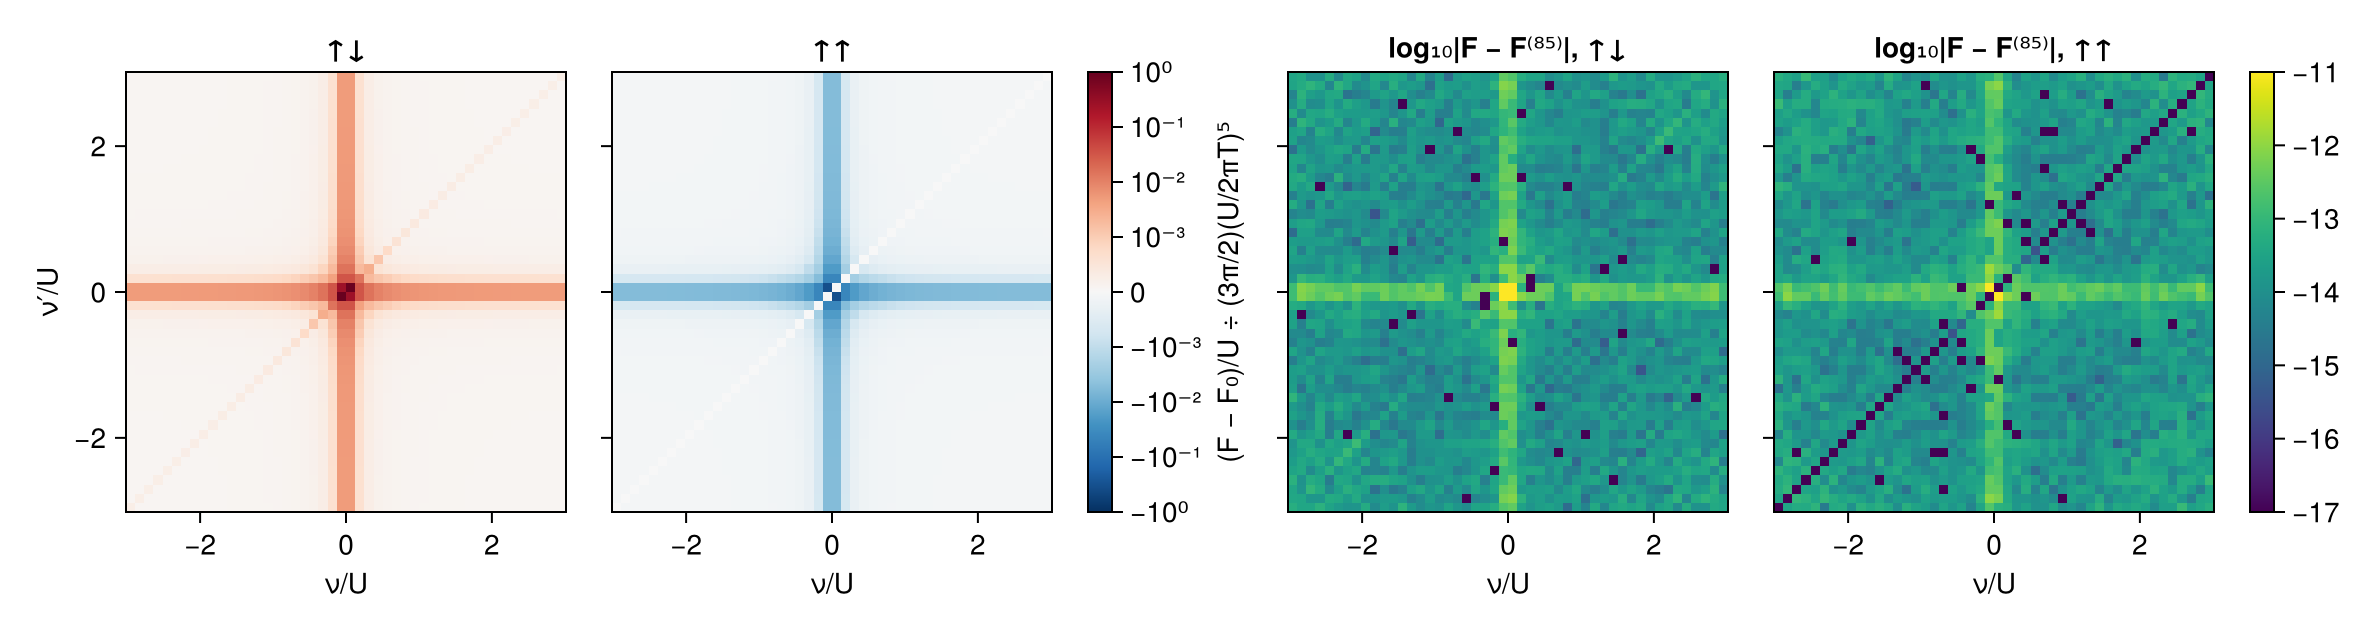

In [38]:
lt = 1e-3
fig = Figure(size = (980, 400))
for (col, (X, lab)) in enumerate(((Xud, "↑↓"), (Xuu, "↑↑")))
    ax = Axis(fig[1, col]; title = lab, xlabel = "ν/U", ylabel = col == 1 ? "ν′/U" : "", aspect = 1, width = 220, height = 220)
    heatmap!(ax, νmf, νmf, symlog.(X, lt); colormap = RDBU, colorrange = (-1, 1), rasterize = 2)
    col == 2 && hideydecorations!(ax; grid = false, ticks = false)
end
Colorbar(fig[1, 3]; colormap = RDBU, limits = (-1, 1), ticks = symlog_ticks(lt, 0:-1:-3),
         label = "(F − F₀)/U ÷ (3π/2)(U/2πT)⁵")
for (col, s) in enumerate((:updn, :upup))
    ax = Axis(fig[1, 3 + col]; title = "log₁₀|F − F⁽⁸⁵⁾|, " * (s === :updn ? "↑↓" : "↑↑"), xlabel = "ν/U", aspect = 1,
              width = 220, height = 220)
    hm = heatmap!(ax, νmf, νmf, Emf[s]; colormap = :viridis, colorrange = (-17, -11), rasterize = 2)
    hideydecorations!(ax; grid = false, ticks = false)
    col == 2 && Colorbar(fig[1, 6], hm)
end
save_fig(fig, "p1_mf_vertex")
fig

The left pair is Fig. 10 of the paper. It shows the plus-shaped structure at $\nu^{(\prime)}=\pm\pi T$, the diagonal, and
for ↑↑ the zero diagonal. The paper draws it from the analytic Eq. (85); here it comes from the PSFs, and the right
pair shows the two agree to about $10^{-13}$ against a signal of up to $10^5$. The anomalous branch of Eq. (46) fires at
every point of this plane, and the $\beta\delta_\omega$ terms of Eq. (85) come out of it.

### P3 — error maps of the fully retarded vertex (done before P2)

A passing P3 validates the legs, the shifts and the label conventions; after that, P2 is a matter of plotting. Grid:
`range(-1, 1; length = 401)` in units of $U$ for both axes. The spacing $U/200=\gamma_0/4$ resolves features of width
$\gamma_0$, and the grid contains $\nu=0$ exactly, where the legs are smallest.

$F^{[\eta]}$ is obtained by amputating $G^{[\eta]}$ with the (D2) legs. It is compared with the continuation of the
first line of Eq. (85a), Eq. (3) of the task sheet: $F^{[\eta]}_{\uparrow\downarrow}=\tfrac12[2u+u^3\sum_iz_i^2/\prod_iz_i-6u^5/\prod_iz_i]$
with $z_\eta=\omega_\eta+3i\gamma_0$ and $z_i=\omega_i-i\gamma_0$ otherwise. p. 19 reports that the numerical results "match
those to floating-point precision". The overlaid lines $\nu=0$ and $\nu'=0$ are where amputation amplifies error most
(P4).

In [39]:
νkf = collect(range(-1, 1; length = 401))                          # in units of U = 1
Fkf_ud = vertex_grid(νkf, νkf, 0.0, HPRM, htab[(:updn, :KF)])
t_kf = @belapsed vertex_grid($νkf, $νkf, 0.0, $HPRM, $(htab[(:updn, :KF)])) samples = 3 evals = 1
@printf("warm (BenchmarkTools.@belapsed): %.2f s per spin, 401 × 401 points, all 16 components, %d thread(s)\n",
        t_kf, Threads.nthreads())
Fkf_uu = vertex_grid(νkf, νkf, 0.0, HPRM, htab[(:upup, :KF)])

P3 = Dict{Int,Matrix{Float64}}()
for η in 1:4
    ref = [fret_updn(ph_frequencies(a, b, 0.0), η, HU, HT) for a in νkf, b in νkf]
    got = Fkf_ud[ntuple(i -> i == η ? 1 : 2, 4)..., :, :]          # F^[η]: a single 1 in slot η
    P3[η] = log10.(max.(abs.(got .- ref), 1e-18) ./ maximum(abs, ref))
    worst = argmax(P3[η])
    @printf("η = %d: max relative error %.1e at (ν, ν′) = (%+.3f, %+.3f);  median %.1e\n", η, 10^P3[η][worst],
            νkf[worst[1]], νkf[worst[2]], 10^sort(vec(P3[η]))[end ÷ 2])
end
jldsave(joinpath(FIGDIR, "p3_error_maps.jld2"); nu = νkf, nup = νkf, log10_relerr = [P3[η] for η in 1:4], gamma0 = HT)

warm (BenchmarkTools.@belapsed): 2.22 s per spin, 401 × 401 points, all 16 components, 1 thread(s)


η = 1: max relative error 2.7e-15 at (ν, ν′) = (-0.005, -0.010);  median 6.5e-21
η = 2: max relative error 2.2e-15 at (ν, ν′) = (+0.000, +0.000);  median 6.5e-21


η = 3: max relative error 2.6e-15 at (ν, ν′) = (+0.000, +0.000);  median 6.5e-21
η = 4: max relative error 2.6e-15 at (ν, ν′) = (+0.010, +0.005);  median 6.5e-21


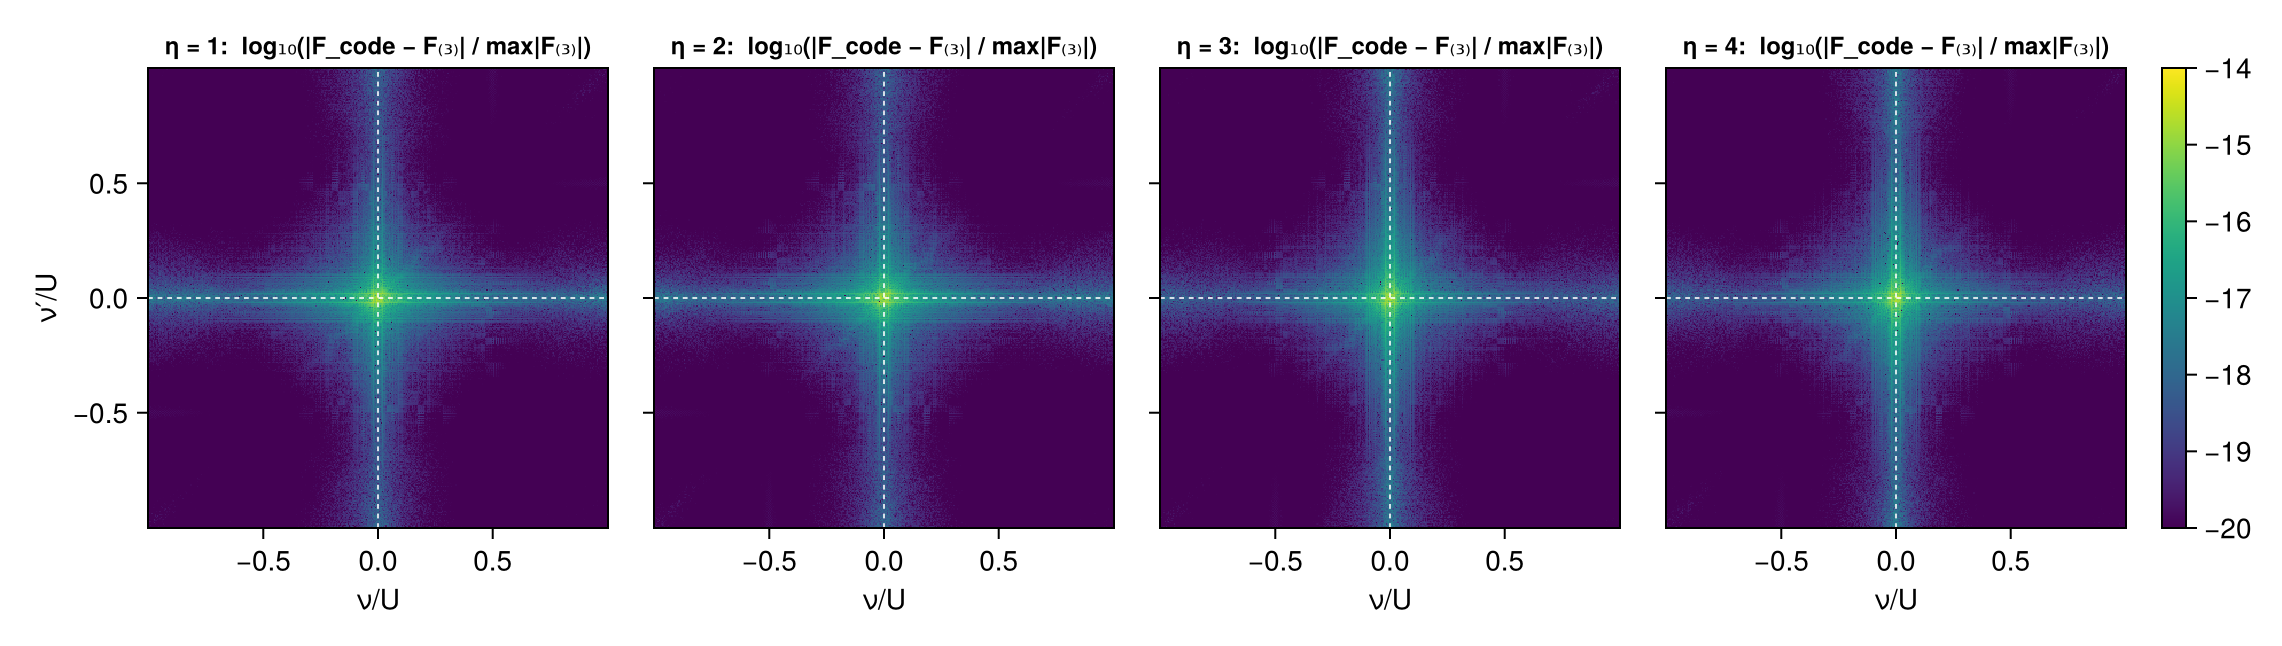

In [40]:
fig = Figure(size = (1180, 330))
for η in 1:4
    ax = Axis(fig[1, η]; title = "η = $η:  log₁₀(|F_code − F₍₃₎| / max|F₍₃₎|)", titlesize = 12, width = 230, height = 230,
              xlabel = "ν/U", ylabel = η == 1 ? "ν′/U" : "", aspect = 1, xticks = -0.5:0.5:0.5, yticks = -0.5:0.5:0.5)
    hm = heatmap!(ax, νkf, νkf, P3[η]; colormap = :viridis, colorrange = (-20, -14), rasterize = 2)
    hlines!(ax, [0.0]; color = :white, linewidth = 0.8, linestyle = :dash)
    vlines!(ax, [0.0]; color = :white, linewidth = 0.8, linestyle = :dash)
    η > 1 && hideydecorations!(ax; grid = false, ticks = false)
    η == 4 && Colorbar(fig[1, 5], hm)
end
save_fig(fig, "p3_error_maps")
fig

P3 passes to floating point. For all four $\eta$ the largest relative error is $\approx3\times10^{-15}$, and the median is
$\sim10^{-20}$, which reproduces Kugler's "match those to floating-point precision" (p. 19). The error has the
structure the task sheet predicted (trap 6). It forms a cross along $\nu=0$ and $\nu'=0$ at the $10^{-17}$ level,
peaking at the origin. There the legs are smallest, $|G^R(0)|\approx4\gamma_0/U^2$ (P4 below), and amputation amplifies
rounding most, while the vertex itself is largest there ($\propto\gamma_0^{-4}$). The shifts, the leg transposition
and the vertex-versus-correlator labels are all consistent. The wrong leg shifts of trap 2 (plain $\pm i\gamma_0$)
would show up here as an $O(1)$ mismatch near the origin.

|G^R(0)| = 0.079872,  4γ₀/U² = 0.080000   [derived: |G^R(0)| ≈ 4γ₀/U² at particle-hole symmetry]


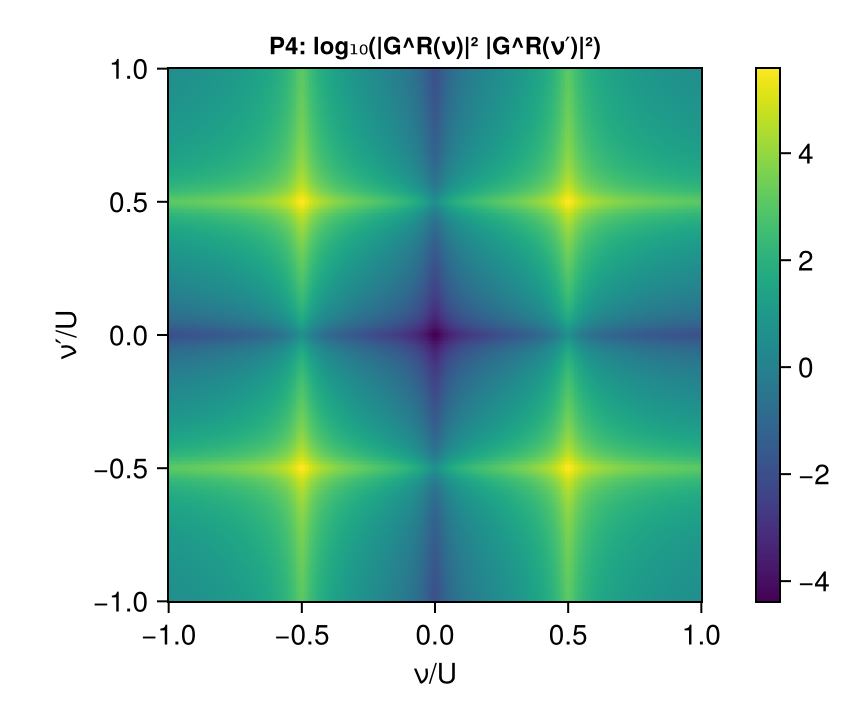

In [41]:
# P4 (optional): amputation conditioning. At ω = 0 legs 1, 2 carry ν and legs 3, 4 carry ν′.
GRν = [leg(ν, 1, 1, htab[(:updn, :KF)].leg, HT)[2, 1] for ν in νkf]
@printf("|G^R(0)| = %.6f,  4γ₀/U² = %.6f   [derived: |G^R(0)| ≈ 4γ₀/U² at particle-hole symmetry]\n",
        abs(GRν[201]), 4HT / HU^2)
C4 = [log10(abs2(GRν[i]) * abs2(GRν[j])) for i in eachindex(νkf), j in eachindex(νkf)]
fig = Figure(size = (430, 360))
ax = Axis(fig[1, 1]; title = "P4: log₁₀(|G^R(ν)|² |G^R(ν′)|²)", titlesize = 12, xlabel = "ν/U", ylabel = "ν′/U", aspect = 1)
hm = heatmap!(ax, νkf, νkf, C4; colormap = :viridis, rasterize = 2)
Colorbar(fig[1, 2], hm)
save_fig(fig, "p4_leg_conditioning")
fig

### P2 — KF vertex, Fig. 11

The quantity is $(F^{k}_{\sigma\sigma'}-F^{k}_{0;\sigma\sigma'})/U$ divided by $(U/\gamma_0)^3$, the pole magnitude quoted on p. 19.
`symlog` with `linthresh = 1e-4`. The layout is Fig. 11's $2\times7$ grid with a separator between the spin blocks:

|  | ↑↓ | | | | ↑↑ | | |
|:--|:--|:--|:--|:--|:--|:--|:--|
| top | 1222 Re | 2111 Re | 2112 Re | 1122 Im | 2111 Re | 2112 Re | 1122 Im |
| bottom | 1222 Im | 2111 Im | 2112 Im | 1111 Im | 2111 Im | 2112 Im | 1111 Im |

1122 and 1111 are purely imaginary (caption). That is checked before only their imaginary parts are plotted.

In [42]:
normk = (HU / HT)^3
Xk(F, k, updn) = (reshape(F[k..., :, :], 401, 401) .- bare_vertex_kf(k, HU, updn)) ./ HU ./ normk
for (F, s) in ((Fkf_ud, :updn), (Fkf_uu, :upup)), k in ((1, 1, 2, 2), (1, 1, 1, 1))
    X = Xk(F, k, s === :updn)
    @printf("%s %s: max|Re| / max|Im| = %.1e\n", s, join(k), maximum(abs, real(X)) / maximum(abs, imag(X)))
end
jldsave(joinpath(FIGDIR, "p2_kf_vertex_full.jld2"); nu = νkf, nup = νkf, F_updn = Fkf_ud, F_upup = Fkf_uu,
        gamma0 = HT, T = HT, U = HU, layout = "F[k1,k2,k3,k4, i_nu, j_nup]")
@printf("saved all 16 components for both spins: %.0f MB\n", filesize(joinpath(FIGDIR, "p2_kf_vertex_full.jld2")) / 1e6)

updn 1122: max|Re| / max|Im| = 1.1e-16
updn 1111: max|Re| / max|Im| = 2.4e-16


upup 1122: max|Re| / max|Im| = 7.8e-17
upup 1111: max|Re| / max|Im| = 6.8e-16
saved all 16 components for both spins: 82 MB


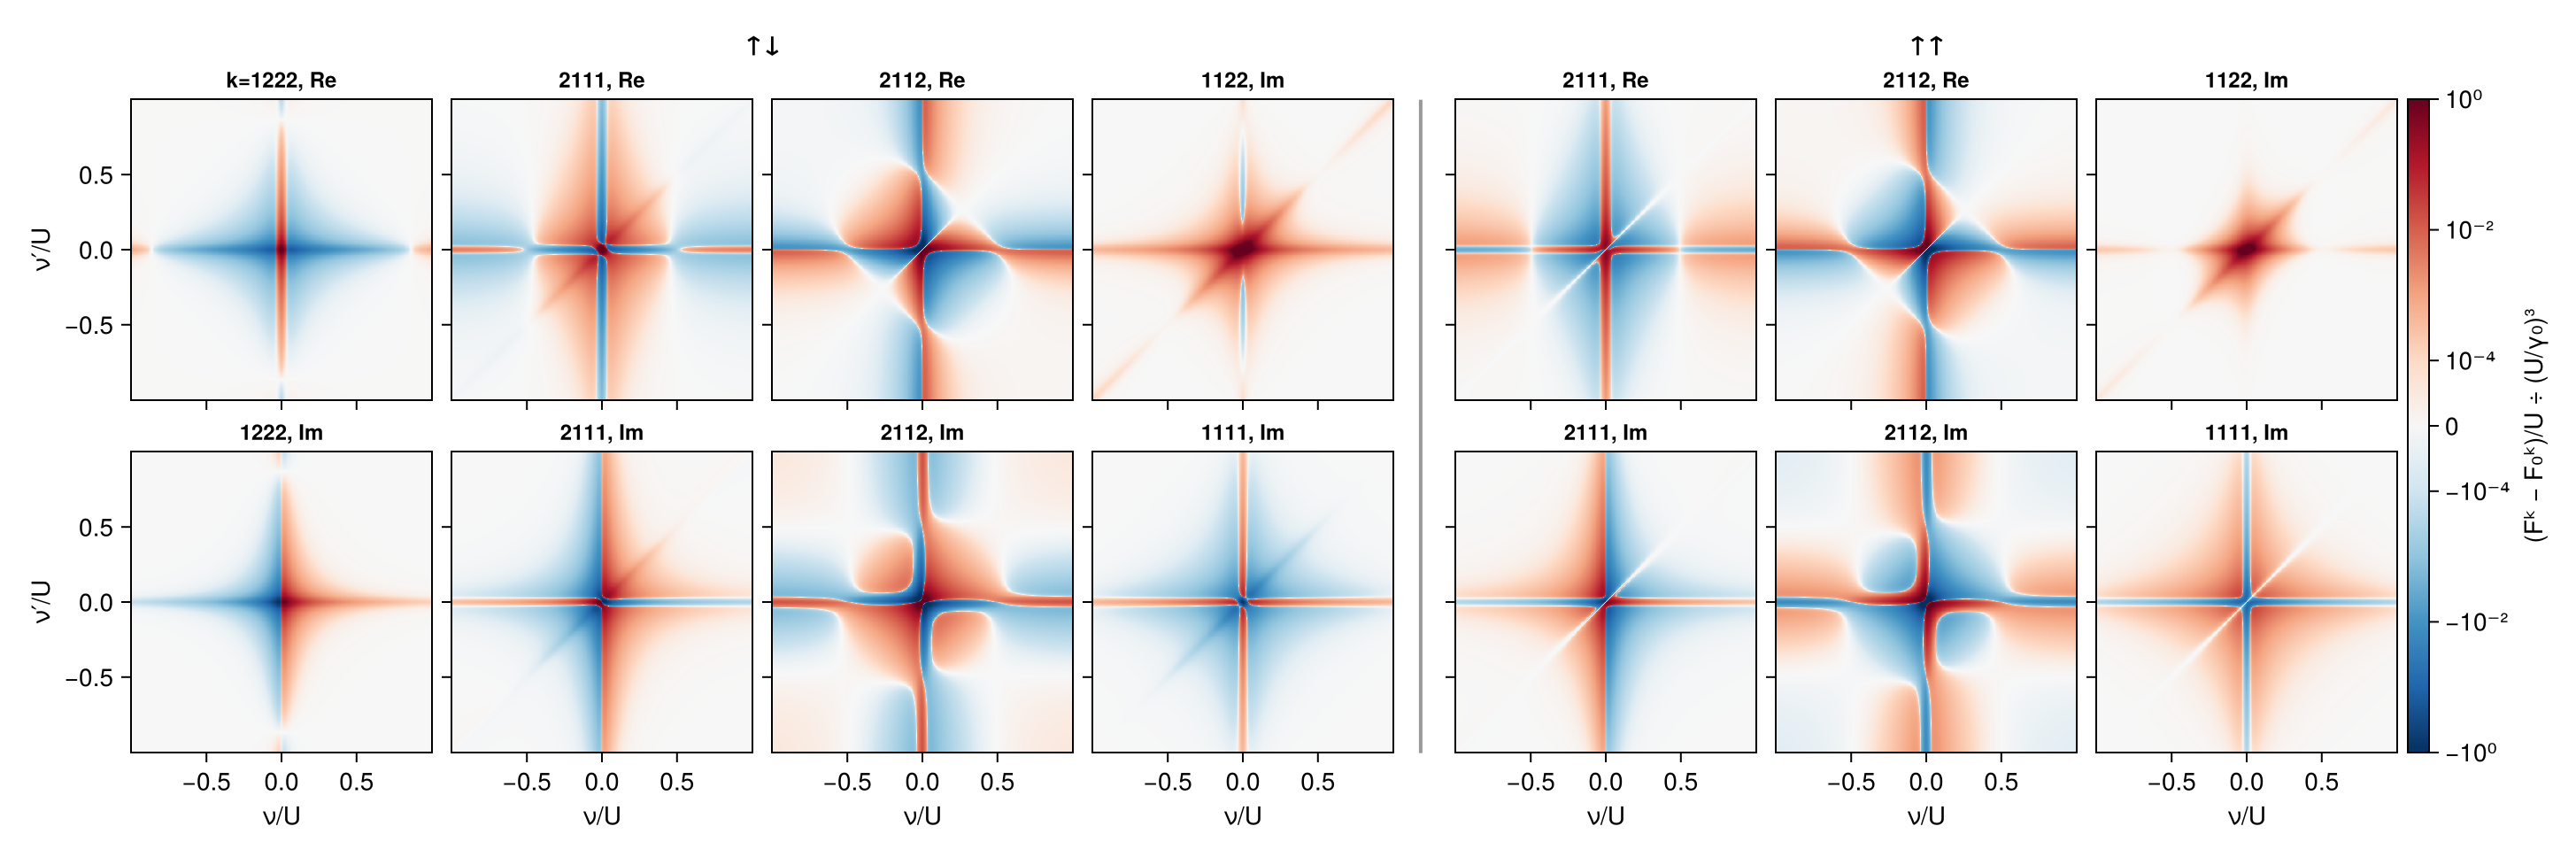

In [43]:
lt = 1e-4
panels_ud = [((1,2,2,2), real, "k=1222, Re"), ((2,1,1,1), real, "2111, Re"), ((2,1,1,2), real, "2112, Re"), ((1,1,2,2), imag, "1122, Im"),
             ((1,2,2,2), imag, "1222, Im"), ((2,1,1,1), imag, "2111, Im"), ((2,1,1,2), imag, "2112, Im"), ((1,1,1,1), imag, "1111, Im")]
panels_uu = [((2,1,1,1), real, "2111, Re"), ((2,1,1,2), real, "2112, Re"), ((1,1,2,2), imag, "1122, Im"),
             ((2,1,1,1), imag, "2111, Im"), ((2,1,1,2), imag, "2112, Im"), ((1,1,1,1), imag, "1111, Im")]
fig = Figure(size = (1500, 470))
g = fig[1, 1] = GridLayout()
function p2_panel!(r, c, F, k, part, title, updn; ylab)
    ax = Axis(g[r, c]; title = title, titlesize = 12, aspect = 1, width = 170, height = 170,
              xlabel = r == 3 ? "ν/U" : "", ylabel = ylab ? "ν′/U" : "", xticks = -0.5:0.5:0.5, yticks = -0.5:0.5:0.5)
    heatmap!(ax, νkf, νkf, symlog.(part.(Xk(F, k, updn)), lt); colormap = RDBU, colorrange = (-1, 1), rasterize = 2)
    ylab || hideydecorations!(ax; grid = false, ticks = false)
    r == 2 && hidexdecorations!(ax; grid = false, ticks = false)          # top row of panels (row 1 holds the labels)
end
for (n, (k, part, title)) in enumerate(panels_ud)
    r, c = n <= 4 ? (1, n) : (2, n - 4)
    p2_panel!(r + 1, c, Fkf_ud, k, part, title, true; ylab = c == 1)
end
for (n, (k, part, title)) in enumerate(panels_uu)
    r, c = n <= 3 ? (1, n) : (2, n - 3)
    p2_panel!(r + 1, c + 5, Fkf_uu, k, part, title, false; ylab = false)
end
Box(g[2:3, 5]; width = 2, color = :gray60, strokevisible = false)
Label(g[1, 1:4], "↑↓"; font = :bold); Label(g[1, 6:8], "↑↑"; font = :bold)
Colorbar(g[2:3, 9]; colormap = RDBU, limits = (-1, 1), ticks = symlog_ticks(lt, 0:-2:-4),
         label = "(Fᵏ − F₀ᵏ)/U ÷ (U/γ₀)³")
colgap!(g, 6); rowgap!(g, 6); colgap!(g, 4, 14); colgap!(g, 5, 14)
save_fig(fig, "p2_kf_vertex")
fig

Compare with Fig. 11 (p. 20). Panel by panel the same features appear:
* the cross at $\nu=0$ and $\nu'=0$, with the sign change across it in the imaginary parts;
* the diagonal and antidiagonal lines of 2111 and 2112;
* the four-lobed "clover" of 2112 Im;
* for ↑↑, the white diagonal of 2111 and 1111 Im, where $F_{\uparrow\uparrow}$ vanishes for $\nu=\nu'$.

The first column, $F^{[1]}$, is the continuation of Eq. (85a) that P3 verified point by point.

The caption's statements about unplotted components can be checked from the saved array, rather than by eye alone.
Those with a single 1 are analogous to 1222. Those with a single 2 are analogous to 2111. 1122 corresponds to 2211,
while the others with two 1's and two 2's resemble 2112. The cell below measures that.

In [44]:
# caption check, quantified: each unplotted ↑↓ component against the plotted one it "looks similar" to, up to the
# symmetries of the square ν, ν′ ∈ [-1, 1] (8 operations), complex conjugation and an overall sign.
maps(F, k) = F[k..., :, :] .- bare_vertex_kf(k, HU, true)
D8(B) = (B, rotr90(B), rot180(B), rotl90(B), permutedims(B), reverse(B; dims = 1), reverse(B; dims = 2), permutedims(rot180(B)))
best_match(A, B) = minimum(maximum(abs, A .- s .* (c ? conj.(C) : C)) for C in D8(B), c in (false, true), s in (1, -1)) / maximum(abs, A)
println("↑↓ component   look-alike   min over symmetries of max|A − B'| / max|A|    max|A| / max|B|")
for (k, ref) in (((2,1,2,2), (1,2,2,2)), ((2,2,1,2), (1,2,2,2)), ((2,2,2,1), (1,2,2,2)),
                 ((1,2,1,1), (2,1,1,1)), ((1,1,2,1), (2,1,1,1)), ((1,1,1,2), (2,1,1,1)),
                 ((2,2,1,1), (1,1,2,2)), ((1,2,2,1), (2,1,1,2)), ((1,2,1,2), (2,1,1,2)), ((2,1,2,1), (2,1,1,2)),
                 ((2,1,2,1), (1,2,1,2)))
    A, B = maps(Fkf_ud, k), maps(Fkf_ud, ref)
    @printf("   %s          %s         %.1e                                     %.2f\n", join(k), join(ref),
            best_match(A, B), maximum(abs, A) / maximum(abs, B))
end

↑↓ component   look-alike   min over symmetries of max|A − B'| / max|A|    max|A| / max|B|
   2122          1222         1.7e-15                                     1.00
   2212          1222         1.6e-15                                     1.00


   2221          1222         6.8e-16                                     1.00
   1211          2111         4.2e-16                                     1.00


   1121          2111         4.2e-16                                     1.00
   1112          2111         4.2e-16                                     1.00


   2211          1122         3.4e-16                                     1.00
   1221          2112         4.9e-16                                     1.00
   1212          2112         6.9e-01                                     3.22
   2121          2112         6.9e-01                                     3.22


   2121          1212         3.8e-16                                     1.00


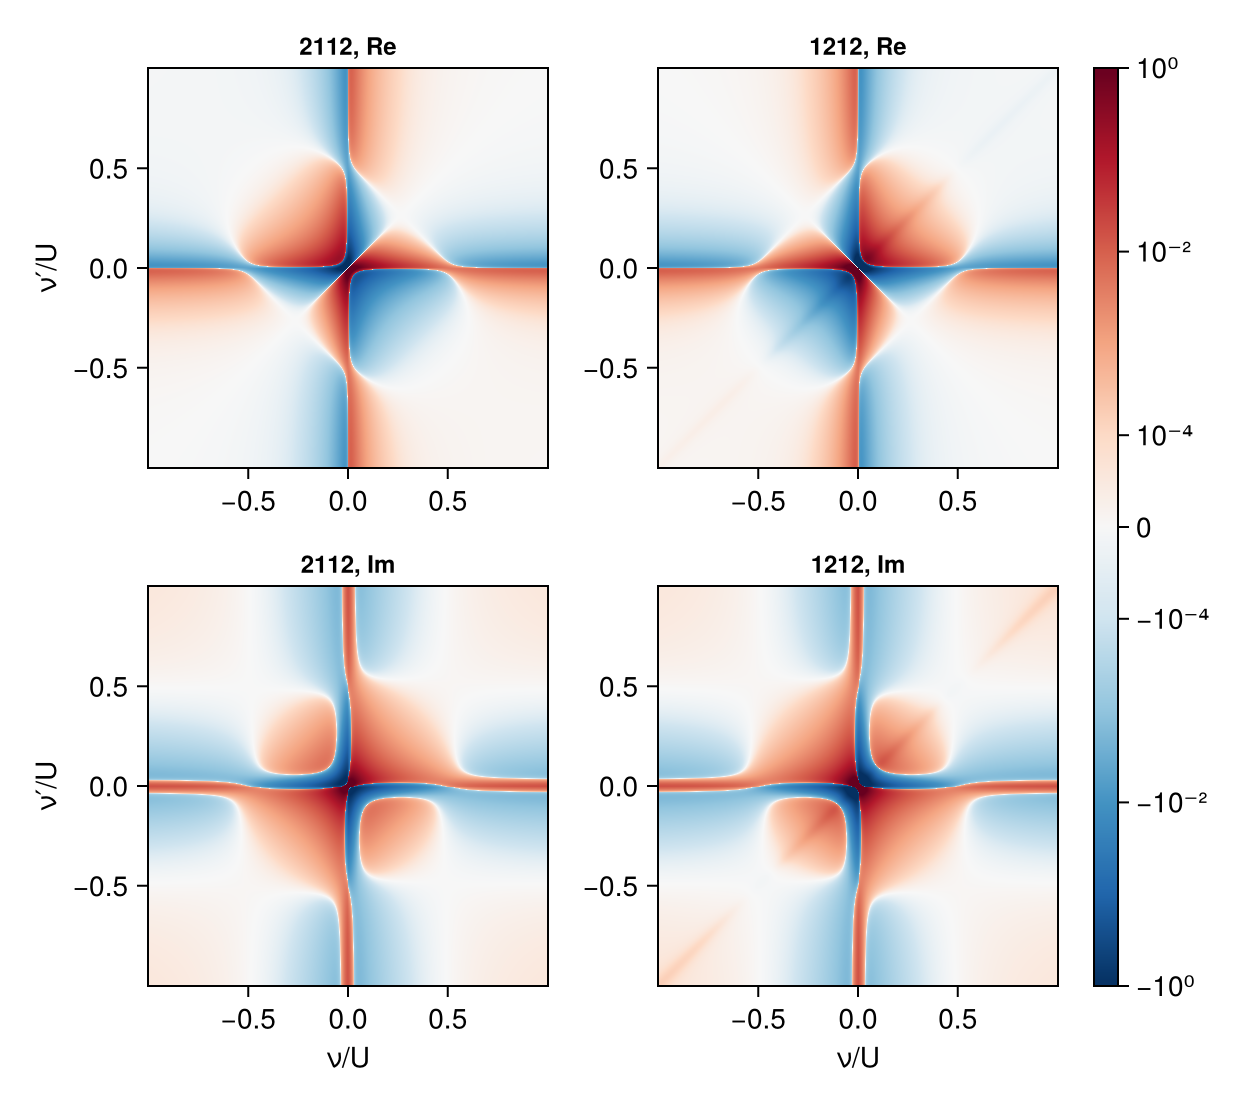

In [45]:
# by eye: 1212 next to 2112, same normalisation and colour scale as P2
fig = Figure(size = (820, 420))
for (c, (k, part, title)) in enumerate((((2,1,1,2), real, "2112, Re"), ((1,2,1,2), real, "1212, Re"),
                                        ((2,1,1,2), imag, "2112, Im"), ((1,2,1,2), imag, "1212, Im")))
    r, cc = c <= 2 ? (1, c) : (2, c - 2)
    ax = Axis(fig[r, cc]; title = title, titlesize = 12, aspect = 1, width = 200, height = 200,
              xlabel = r == 2 ? "ν/U" : "", ylabel = cc == 1 ? "ν′/U" : "", xticks = -0.5:0.5:0.5, yticks = -0.5:0.5:0.5)
    heatmap!(ax, νkf, νkf, symlog.(part.(Xk(Fkf_ud, k, true)), 1e-4); colormap = RDBU, colorrange = (-1, 1), rasterize = 2)
end
Colorbar(fig[1:2, 3]; colormap = RDBU, limits = (-1, 1), ticks = symlog_ticks(1e-4, 0:-2:-4))
save_fig(fig, "p2_caption_check")
fig

The caption holds exactly where a symmetry maps one component onto another. The single-1 components are images of 1222,
the single-2 ones of 2111, 2211 of 1122, and 1221 of 2112, all to rounding. 1212 and 2121 are images of each other but
**not** of 2112: they form their own class, about 3× larger. Side by side they show the same skeleton — the cross
through the origin and the two diagonals — with different lobes. So "look similar" in the caption is a visual
statement for this class, not a symmetry.

### Timings

Inside this notebook every function has already been compiled by the test cell, so an `@time` here would not show
the first-call cost. `scripts/heatmap_timing.jl` therefore runs in a fresh Julia process. It reports the first call
(`@elapsed`, compilation included) and the warm time (`BenchmarkTools.@belapsed`) for both production runs, plus the
cost of loading CairoMakie and drawing a first heat map. The warm time is the one to compare with the one-hour
figure.

In [46]:
print(read(`$(Base.julia_cmd()) --project=$(joinpath(@__DIR__, "..")) $(joinpath(@__DIR__, "..", "scripts", "heatmap_timing.jl"))`, String))

load src: 0.73 s   build PSF tables (both spins, MF + KF): 3.68 s   threads: 1
P1  MF grid  48 × 48, one spin:              first call    0.247 s   warm   0.0081 s
P2  KF grid 401 × 401 × 16, one spin:        first call    2.540 s   warm    2.173 s
    using CairoMakie: 3.7 s   first heatmap + save: 3.3 s   second: 0.12 s


### P5 (optional) — $\gamma_0$ scaling

$\max|F^{k}-F_0^{k}|$ over the grid against $\gamma_0/T\in\{0.5,1,2,4\}$, one line per plotted component, on log–log
axes. The comparison is with the $\gamma_0^{-3}$ quoted on p. 19 ("the poles reach a magnitude of $\gamma_0^{-3}$"). This
is an observation, not a benchmark.

   spin  k      max|F^k − F₀^k| at γ₀/T = 0.5, 1, 2, 4           slope     slope of max|G^con,k|


   ↑↓  1222   3.127e+06 1.959e+05 1.236e+04 8.020e+02    -3.98     -3.00
   ↑↓  2111   6.598e+06 4.125e+05 2.584e+04 1.637e+03    -3.99     -3.00


   ↑↓  2112   1.704e+07 5.024e+05 1.189e+04 3.948e+02    -5.13     -3.01
   ↑↓  1122   3.453e+07 1.061e+06 3.085e+04 9.349e+02    -5.06     -3.01
   ↑↓  1111   8.444e+05 1.062e+05 1.363e+04 1.897e+03    -2.93     G^1111 ≡ 0
   ↑↑  2111   9.716e+05 6.252e+04 4.204e+03 3.406e+02    -3.83     ≈ 0 (1e-15 of max|G|)
   ↑↑  2112   1.749e+07 5.583e+05 1.896e+04 8.021e+02    -4.80     -3.00
   ↑↑  1122   1.749e+07 5.583e+05 1.896e+04 8.021e+02    -4.80     -3.00
   ↑↑  1111   8.562e+04 1.076e+04 1.405e+03 1.938e+02    -2.93     G^1111 ≡ 0
Eq. (3) at ν = ν′ = 0: |6u⁵/∏zᵢ| / 2 = 1.953e+05 vs grid maximum of 1222 at γ₀ = T: 1.959e+05 — the vertex pole is γ₀⁻⁴


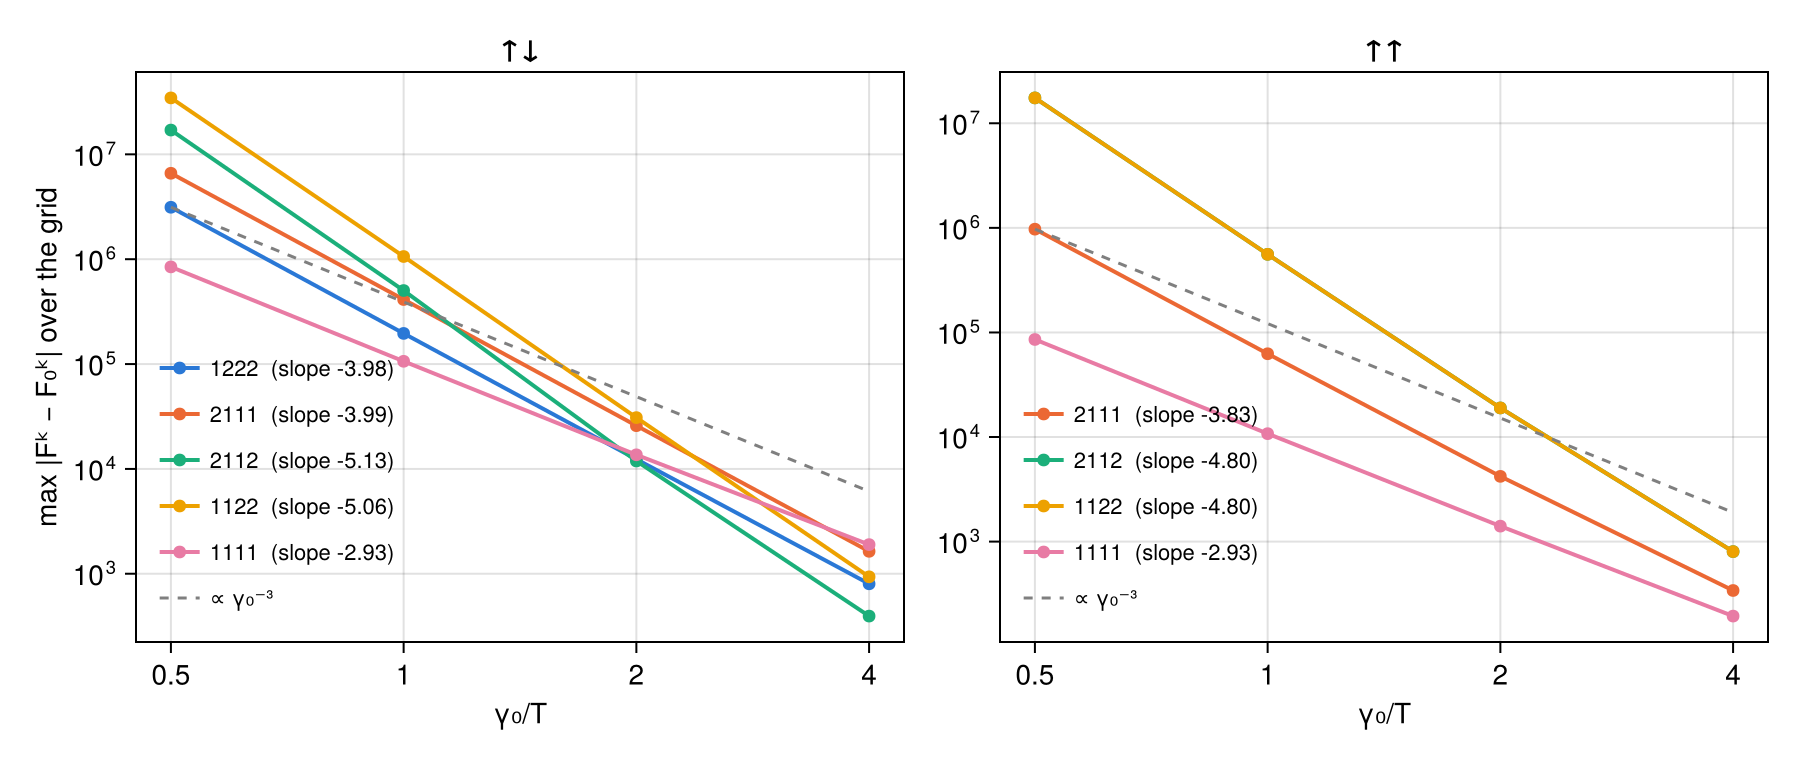

In [47]:
γs = [0.5, 1.0, 2.0, 4.0] .* HT
comps = [((1,2,2,2), "1222"), ((2,1,1,1), "2111"), ((2,1,1,2), "2112"), ((1,1,2,2), "1122"), ((1,1,1,1), "1111")]
P5 = Dict{Tuple{Symbol,String},Vector{Float64}}(); P5G = Dict{Tuple{Symbol,String},Vector{Float64}}(); P5Gall = Dict{Symbol,Vector{Float64}}()
for γ in γs
    prm = HeatmapParams(HU, 1 / HT, γ)
    for s in (:updn, :upup)
        F = vertex_grid(νkf, νkf, 0.0, prm, htab[(s, :KF)])
        G = kf_correlator_grid(νkf, νkf, 0.0, prm, htab[(s, :KF)])       # G^con, for comparison
        push!(get!(P5Gall, s, Float64[]), maximum(abs, G))
        for (k, lab) in comps
            (s === :upup && lab == "1222") && continue
            push!(get!(P5, (s, lab), Float64[]), maximum(abs, F[k..., :, :] .- bare_vertex_kf(k, HU, s === :updn)))
            push!(get!(P5G, (s, lab), Float64[]), maximum(abs, G[k..., :, :]))
        end
    end
end
slope(v) = all(iszero, v) ? NaN : (log(v[end]) - log(v[1])) / (log(γs[end]) - log(γs[1]))
println("   spin  k      max|F^k − F₀^k| at γ₀/T = 0.5, 1, 2, 4           slope     slope of max|G^con,k|")
for s in (:updn, :upup), (k, lab) in comps
    haskey(P5, (s, lab)) || continue
    v = P5[(s, lab)]
    g = P5G[(s, lab)]
    gtxt = all(iszero, g) ? "G^1111 ≡ 0" :
           all(g .< 1e-12 .* P5Gall[s]) ? @sprintf("≈ 0 (%.0e of max|G|)", maximum(g ./ P5Gall[s])) : @sprintf("%+.2f", slope(g))
    @printf("   %s  %s   %s    %+.2f     %s\n", s === :updn ? "↑↓" : "↑↑", lab,
            join([@sprintf("%9.3e", x) for x in v], " "), slope(v), gtxt)
end
u = HU / 2; z0 = (3im * HT, -1im * HT, -1im * HT, -1im * HT)
@printf("Eq. (3) at ν = ν′ = 0: |6u⁵/∏zᵢ| / 2 = %.3e vs grid maximum of 1222 at γ₀ = T: %.3e — the vertex pole is γ₀⁻⁴\n",
        abs(6u^5 / prod(z0)) / 2, P5[(:updn, "1222")][2])
jldsave(joinpath(FIGDIR, "p5_gamma0_scaling.jld2"); gamma0 = γs, maxabs_F = Dict(string(k) => v for (k, v) in P5),
        maxabs_Gcon = Dict(string(k) => v for (k, v) in P5G))

palette = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
fig = Figure(size = (900, 380))
for (col, s) in enumerate((:updn, :upup))
    ax = Axis(fig[1, col]; xscale = log10, yscale = log10, xlabel = "γ₀/T", title = s === :updn ? "↑↓" : "↑↑",
              ylabel = col == 1 ? "max |Fᵏ − F₀ᵏ| over the grid" : "", xticks = ([0.5, 1, 2, 4], ["0.5", "1", "2", "4"]))
    for (i, (k, lab)) in enumerate(comps)
        haskey(P5, (s, lab)) || continue
        v = P5[(s, lab)]
        scatterlines!(ax, γs ./ HT, v; color = palette[i], linewidth = 2, markersize = 9,
                      label = @sprintf("%s  (slope %+.2f)", lab, slope(v)))
    end
    ref = P5[(s, s === :updn ? "1222" : "2111")]
    lines!(ax, γs ./ HT, ref[1] .* (γs ./ γs[1]) .^ -3; color = :gray50, linestyle = :dash, label = "∝ γ₀⁻³")
    axislegend(ax; position = :lb, labelsize = 11, framevisible = false)
end
save_fig(fig, "p5_gamma0_scaling")
fig

**Reading P5.** The $\gamma_0^{-3}$ of p. 19 describes the *correlator*: "the denominators contain three factors of
the type $(\omega_i+i\gamma_0-\omega'_i)$, [so] the poles reach a magnitude of $\gamma_0^{-3}$". The last column
confirms it: $\max|G^{{\rm con},k}|$ scales as $\gamma_0^{-3.00}$ for every component that does not vanish. Two
vanish: $G^{1111}\equiv0$ (Eq. 63), and the ↑↑ correlator 2111, which is $G^{[1]}_{\uparrow\uparrow}$. The latter is zero to rounding,
$\sim10^{-15}$ of the largest component, exactly as $F^{[\eta]}_{\uparrow\uparrow}\equiv0$ requires. (The ↑↑ *vertex* component
2111 has a single 2, so it is not an $F^{[\eta]}$, and it is finite.)
The *vertex* maxima scale faster, because amputation divides by legs that are themselves $O(\gamma_0)$ at the origin:
* the fully retarded 1222 and its ↑↓ relative 2111 go as $\gamma_0^{-4}$, exactly as Eq. (3) predicts at
  $\nu=\nu'=0$ ($6u^5/\prod z_i$ with $\prod z_i=3\gamma_0^4$);
* 2112 and 1122 go as roughly $\gamma_0^{-5}$;
* 1111 goes as roughly $\gamma_0^{-3}$.

The normalisation $(U/\gamma_0)^3$ of Fig. 11 is therefore the correlator's pole scale, not the vertex's. At the
paper's $\gamma_0=T$ it still puts every panel on a common $O(1)$ scale. In the ↑↑ block, 2112 and 1122 have
identical maxima at every $\gamma_0$.

### Summary of the heat-map section

| Check | Result |
|:--|:--|
| H1 | `vertex_point!` allocates 0 bytes and every variable infers to a concrete type (MF and KF); it agrees with an independent reference (Eq. 67b correlator + Lehmann legs + generic inverses) at 20 points × 16 components × 2 spins to 1e-11 on values up to 5e3 |
| H2 | MF: kernel (46) on $S^{\rm dis}$ = first line of Eq. (73) to 4e-14; vertex via $S^{\rm con}$ = correlator-level subtraction. KF: $\sum_p\zeta^pK^{[\eta]}*S^{\rm dis}=0$ to 4e-16 relative to terms of size $10^{2}$–$10^{4}$ |
| H3 | `leg(ν,1,1)` = the $\ell=2$ routine to 7e-15; $F^{2222}\equiv0$; $F^{[\eta]}_{\uparrow\uparrow}=0$ to 3e-16 relative |
| H4 / P3 | $F^{[\eta]}_{\uparrow\downarrow}$ = Eq. (3), $\eta=1\ldots4$, over the full 401×401 grid: max relative error 3e-15, located at the origin |
| P1 | Fig. 10 reproduced; targets met: max 0.9510 at $\nu=\nu'=\pi T$, min 8.76e-5, ↑↑ min −0.3439, zero ↑↑ diagonal; error vs Eq. (85) ≤ 6e-11 on values up to 1.4e5 |
| P2 | Fig. 11 reproduced panel by panel; 1122, 1111 purely imaginary (Re/Im ≤ 7e-16); all 16 components saved; caption checked: exact symmetry images except 1212/2121 vs 2112 |
| P4 | $|G^R(0)|=0.0799\approx4\gamma_0/U^2=0.08$ |
| P5 | $G^{\rm con}$ poles $\propto\gamma_0^{-3.00}$ as on p. 19; vertex maxima $\propto\gamma_0^{-3}$ to $\gamma_0^{-5}$ by component |
| timing | fresh process, one spin: MF 48² first call 0.25 s, warm 9 ms; KF 401²×16 first call 2.6 s, warm 2.2 s (one thread) |

Figures are written to `notebooks/figures/heatmaps/` as PNG and PDF, and the arrays as `.jld2`.
`p2_kf_vertex_full.jld2` (all 16 components, both spins, 82 MB) is regenerated by this notebook and kept out of git.